# K=3 soft-membership three-model experiment — v1.3

This notebook trains **Soft Logistic Regression**, an **Embedding MLP**, and **ResNet18 with Layer 4 unfrozen** under the same chronological and soft-label protocol. Class imbalance is handled in every trainer with training-only inverse soft-membership-mass weights. Version 1.3 supports `input_image_path` and source-aware chronological boundary validation. Run the cells in order.


In [1]:
import torch

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('A GPU is strongly recommended for embedding extraction and Layer-4 training.')


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [6]:
!nvidia-smi


Wed Aug 12 17:43:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P0             27W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Discover the attached dataset and package

The dataset is identified by its validated soft-membership manifests. The package is identified by the v1.3 `soft_supervised/run_all_models.py` workflow.


In [7]:
from pathlib import Path

input_root = Path('/kaggle/input')
dataset_candidates = []
package_candidates = []
for path in input_root.rglob('*'):
    if path.name == 'train_soft_shuffled.csv' and path.parent.name == 'manifests':
        soft_dir = path.parent.parent
        dataset_candidates.append(soft_dir.parent if soft_dir.name == 'soft_membership' else soft_dir)
    if path.name == 'run_all_models.py' and path.parent.name == 'soft_supervised':
        candidate = path.parent.parent
        config_path = candidate / 'configs' / 'training_config.json'
        if config_path.is_file():
            import json
            with config_path.open('r', encoding='utf-8') as handle:
                candidate_config = json.load(handle)
            if candidate_config.get('package_version') == '1.3':
                package_candidates.append(candidate)

dataset_candidates = sorted(set(dataset_candidates))
package_candidates = sorted(set(package_candidates))
print('Dataset candidates:')
for i, path in enumerate(dataset_candidates): print(i, path)
print('\nPackage candidates:')
for i, path in enumerate(package_candidates): print(i, path)
if not dataset_candidates or not package_candidates:
    raise RuntimeError('Attach both the processed dataset and the v1.3 three-model package.')


Dataset candidates:
0 /kaggle/input/datasets/mozimandias/btcusdt-k3-soft-membership-forecasting-dataset/BTCUSDT_k3_forecasting_dataset

Package candidates:
0 /kaggle/input/datasets/mozimandias/k3-soft-membership-three-model-trainer-v1-3/k3_soft_membership_kaggle_three_model_v1_3


If more than one candidate appears, change the two indices below before continuing.

In [8]:
DATASET_ROOT = dataset_candidates[0]
PACKAGE_INPUT = package_candidates[0]
print('Selected dataset:', DATASET_ROOT)
print('Selected package:', PACKAGE_INPUT)


Selected dataset: /kaggle/input/datasets/mozimandias/btcusdt-k3-soft-membership-forecasting-dataset/BTCUSDT_k3_forecasting_dataset
Selected package: /kaggle/input/datasets/mozimandias/k3-soft-membership-three-model-trainer-v1-3/k3_soft_membership_kaggle_three_model_v1_3


## Copy the package to Kaggle working storage and configure it

In [9]:
import json
import shutil

PACKAGE_WORKING = Path('/kaggle/working/k3_soft_membership_kaggle_three_model_v1_3')
if PACKAGE_WORKING.exists():
    shutil.rmtree(PACKAGE_WORKING)
shutil.copytree(PACKAGE_INPUT, PACKAGE_WORKING)
CONFIG_PATH = PACKAGE_WORKING / 'configs' / 'training_config.json'
SCRIPTS = PACKAGE_WORKING / 'soft_supervised'
RESULTS_ROOT = Path('/kaggle/working/k3_soft_three_model_results_v1_3')
with CONFIG_PATH.open('r', encoding='utf-8') as handle:
    config = json.load(handle)
config['dataset_dir'] = str(DATASET_ROOT)
config['soft_membership_dir'] = ''
config['output_dir'] = str(RESULTS_ROOT)
config['device'] = 'auto'
config['num_workers'] = 2
with CONFIG_PATH.open('w', encoding='utf-8') as handle:
    json.dump(config, handle, indent=2)
print(json.dumps(config, indent=2))


{
  "_instructions": [
    "Three-model Kaggle experiment for the validated K=3 soft-membership dataset.",
    "The soft Logistic Regression and MLP reuse one frozen 512-D ResNet18 embedding cache.",
    "The image model trains only ResNet18 layer4 and its three-output head.",
    "All models use soft targets, certainty weights, and training-only soft class weights.",
    "Select checkpoints using validation macro-F1 only, then run evaluate_all_models.py once."
  ],
  "package_version": "1.3",
  "class_imbalance_strategy": "training_only_inverse_soft_membership_mass",
  "dataset_dir": "/kaggle/input/datasets/mozimandias/btcusdt-k3-soft-membership-forecasting-dataset/BTCUSDT_k3_forecasting_dataset",
  "soft_membership_dir": "",
  "output_dir": "/kaggle/working/k3_soft_three_model_results_v1_3",
  "training_mode": "unfreeze_layer4",
  "evaluation_training_mode": "unfreeze_layer4",
  "device": "auto",
  "batch_size": 16,
  "evaluation_batch_size": 32,
  "embedding_batch_size": 128,
  "emb

## Preflight check

This validates paths, manifests, split boundaries, weights, and all three output heads.

In [10]:
!python -u "{SCRIPTS / 'check_setup.py'}"


Kaggle GPU available: True
GPU: Tesla T4

dataset_dir: True — /kaggle/input/datasets/mozimandias/btcusdt-k3-soft-membership-forecasting-dataset/BTCUSDT_k3_forecasting_dataset
soft_membership_dir: True — /kaggle/input/datasets/mozimandias/btcusdt-k3-soft-membership-forecasting-dataset/BTCUSDT_k3_forecasting_dataset/soft_membership
train_manifest: True — /kaggle/input/datasets/mozimandias/btcusdt-k3-soft-membership-forecasting-dataset/BTCUSDT_k3_forecasting_dataset/soft_membership/manifests/train_soft_shuffled.csv
validation_manifest: True — /kaggle/input/datasets/mozimandias/btcusdt-k3-soft-membership-forecasting-dataset/BTCUSDT_k3_forecasting_dataset/soft_membership/manifests/validation_soft_annotated_chronological.csv
test_manifest: True — /kaggle/input/datasets/mozimandias/btcusdt-k3-soft-membership-forecasting-dataset/BTCUSDT_k3_forecasting_dataset/soft_membership/manifests/test_soft_annotated_chronological.csv
weights_report: True — /kaggle/input/datasets/mozimandias/btcusdt-k3-sof

In [13]:
!python -u "{SCRIPTS / 'extract_embeddings.py'}"

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|███████████████████████████████████████| 44.7M/44.7M [00:00<00:00, 228MB/s]
Extracting train embeddings: 100%|█████████| 329/329 [02:45<00:00,  1.99batch/s]
Saved train: (42100, 512) -> /kaggle/working/k3_soft_three_model_results_v1_3/frozen_resnet18_embeddings/train_embeddings.npz
Extracting validation embeddings: 100%|██████| 38/38 [00:20<00:00,  1.82batch/s]
Saved validation: (4775, 512) -> /kaggle/working/k3_soft_three_model_results_v1_3/frozen_resnet18_embeddings/validation_embeddings.npz
Held-out test embeddings were not extracted during training/validation.


In [14]:
from pathlib import Path
import json
import numpy as np

embedding_dir = (
    RESULTS_ROOT / "frozen_resnet18_embeddings"
)

train_path = embedding_dir / "train_embeddings.npz"
validation_path = embedding_dir / "validation_embeddings.npz"
test_path = embedding_dir / "test_embeddings.npz"
standardizer_path = embedding_dir / "training_fitted_standardizer.npz"
metadata_path = embedding_dir / "embedding_metadata.json"

print("=" * 80)
print("EMBEDDING FILE AUDIT")
print("=" * 80)

files = {
    "train_embeddings": train_path,
    "validation_embeddings": validation_path,
    "test_embeddings": test_path,
    "training_standardizer": standardizer_path,
    "metadata": metadata_path,
}

for name, path in files.items():
    print(f"{name}: {path.is_file()} — {path}")

if not train_path.is_file():
    raise FileNotFoundError("Training embeddings were not created.")

if not validation_path.is_file():
    raise FileNotFoundError("Validation embeddings were not created.")

if test_path.exists():
    raise RuntimeError(
        "Test embeddings were extracted before final evaluation."
    )

if not standardizer_path.is_file():
    raise FileNotFoundError(
        "Training-fitted standardizer was not created."
    )

if not metadata_path.is_file():
    raise FileNotFoundError("Embedding metadata was not created.")

with np.load(train_path) as train_cache:
    train_shapes = {
        name: train_cache[name].shape
        for name in train_cache.files
    }
    train_x = train_cache["X"]

with np.load(validation_path) as validation_cache:
    validation_shapes = {
        name: validation_cache[name].shape
        for name in validation_cache.files
    }
    validation_x = validation_cache["X"]

with np.load(standardizer_path) as standardizer:
    mean = standardizer["mean"]
    scale = standardizer["scale"]

with metadata_path.open("r", encoding="utf-8") as handle:
    metadata = json.load(handle)

print("\n" + "=" * 80)
print("ARRAY SHAPES")
print("=" * 80)

print("Training arrays:")
for name, shape in train_shapes.items():
    print(f"  {name}: {shape}")

print("\nValidation arrays:")
for name, shape in validation_shapes.items():
    print(f"  {name}: {shape}")

print("\nStandardizer:")
print("  mean:", mean.shape)
print("  scale:", scale.shape)

print("\n" + "=" * 80)
print("NUMERICAL CHECKS")
print("=" * 80)

print("Training embeddings finite:", np.isfinite(train_x).all())
print("Validation embeddings finite:", np.isfinite(validation_x).all())
print("Training feature dtype:", train_x.dtype)
print("Validation feature dtype:", validation_x.dtype)
print("Training feature mean:", float(train_x.mean()))
print("Training feature standard deviation:", float(train_x.std()))
print("Validation feature mean:", float(validation_x.mean()))
print("Validation feature standard deviation:", float(validation_x.std()))
print("Standardizer mean finite:", np.isfinite(mean).all())
print("Standardizer scale finite:", np.isfinite(scale).all())
print("All standardizer scales positive:", bool((scale > 0).all()))

print("\n" + "=" * 80)
print("METADATA")
print("=" * 80)

print(json.dumps(metadata, indent=2))

assert train_x.shape == (42100, 512)
assert validation_x.shape == (4775, 512)
assert train_x.dtype == np.float32
assert validation_x.dtype == np.float32
assert np.isfinite(train_x).all()
assert np.isfinite(validation_x).all()
assert mean.shape == (512,)
assert scale.shape == (512,)
assert np.isfinite(mean).all()
assert np.isfinite(scale).all()
assert (scale > 0).all()
assert metadata["backbone_frozen"] is True
assert metadata["embedding_dimension"] == 512
assert metadata["extracted_splits"] == ["train", "validation"]
assert metadata["standardizer_fitted_on_training_only"] is True
assert metadata["test_extraction_requested_only_for_final_evaluation"] is False
assert not test_path.exists()

print("\nEMBEDDING AUDIT PASSED")
print("Training and validation embeddings are ready.")
print("The independent test embeddings remain unextracted.")

EMBEDDING FILE AUDIT
train_embeddings: True — /kaggle/working/k3_soft_three_model_results_v1_3/frozen_resnet18_embeddings/train_embeddings.npz
validation_embeddings: True — /kaggle/working/k3_soft_three_model_results_v1_3/frozen_resnet18_embeddings/validation_embeddings.npz
test_embeddings: False — /kaggle/working/k3_soft_three_model_results_v1_3/frozen_resnet18_embeddings/test_embeddings.npz
training_standardizer: True — /kaggle/working/k3_soft_three_model_results_v1_3/frozen_resnet18_embeddings/training_fitted_standardizer.npz
metadata: True — /kaggle/working/k3_soft_three_model_results_v1_3/frozen_resnet18_embeddings/embedding_metadata.json

ARRAY SHAPES
Training arrays:
  X: (42100, 512)
  soft_targets: (42100, 3)
  certainty_weights: (42100,)
  hard_targets: (42100,)
  row_indices: (42100,)

Validation arrays:
  X: (4775, 512)
  soft_targets: (4775, 3)
  certainty_weights: (4775,)
  hard_targets: (4775,)
  row_indices: (4775,)

Standardizer:
  mean: (512,)
  scale: (512,)

NUMERIC

In [15]:
!python -u "{SCRIPTS / 'train_embedding_model.py'}" \
    --model soft_logistic_regression

soft_logistic_regression epoch 01/40 | train loss=1.0520 macro-F1=0.3594 | val loss=1.0927 macro-F1=0.3385
soft_logistic_regression epoch 02/40 | train loss=1.0347 macro-F1=0.3992 | val loss=1.0815 macro-F1=0.3286
soft_logistic_regression epoch 03/40 | train loss=1.0320 macro-F1=0.4070 | val loss=1.0842 macro-F1=0.3375
soft_logistic_regression epoch 04/40 | train loss=1.0311 macro-F1=0.4122 | val loss=1.0863 macro-F1=0.3382
soft_logistic_regression epoch 05/40 | train loss=1.0277 macro-F1=0.4190 | val loss=1.0786 macro-F1=0.3334
soft_logistic_regression epoch 06/40 | train loss=1.0272 macro-F1=0.4200 | val loss=1.0810 macro-F1=0.3300
soft_logistic_regression epoch 07/40 | train loss=1.0271 macro-F1=0.4199 | val loss=1.0789 macro-F1=0.3408
soft_logistic_regression epoch 08/40 | train loss=1.0266 macro-F1=0.4199 | val loss=1.0817 macro-F1=0.3398
soft_logistic_regression epoch 09/40 | train loss=1.0266 macro-F1=0.4211 | val loss=1.0837 macro-F1=0.3419
soft_logistic_regression epoch 10/40 

In [16]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

logistic_dir = RESULTS_ROOT / "soft_logistic_regression"

paths = {
    "best_model": logistic_dir / "best_model.pt",
    "last_checkpoint": logistic_dir / "last_checkpoint.pt",
    "training_history": logistic_dir / "training_history.csv",
    "training_report": logistic_dir / "training_report.json",
    "validation_predictions": logistic_dir / "validation_predictions.csv",
    "validation_confusion_matrix": (
        logistic_dir / "validation_confusion_matrix.png"
    ),
}

print("=" * 80)
print("SOFT LOGISTIC REGRESSION FILE AUDIT")
print("=" * 80)

for name, path in paths.items():
    print(f"{name}: {path.is_file()} — {path}")

missing = [
    name
    for name, path in paths.items()
    if not path.is_file()
]

if missing:
    raise FileNotFoundError(
        f"Missing Logistic Regression outputs: {missing}"
    )

history = pd.read_csv(paths["training_history"])

with paths["training_report"].open("r", encoding="utf-8") as handle:
    report = json.load(handle)

checkpoint = torch.load(
    paths["best_model"],
    map_location="cpu",
    weights_only=False,
)

predictions = pd.read_csv(paths["validation_predictions"])

print("\n" + "=" * 80)
print("CHECKPOINT CONTRACT")
print("=" * 80)

print("Model name:", checkpoint.get("model_name"))
print("Target kind:", checkpoint.get("target_kind"))
print("Number of classes:", checkpoint.get("num_classes"))
print("Best epoch in checkpoint:", checkpoint.get("best_epoch"))
print(
    "Best validation macro-F1 in checkpoint:",
    checkpoint.get("best_validation_macro_f1"),
)

print("\n" + "=" * 80)
print("TRAINING HISTORY")
print("=" * 80)

display(history)

best_history_row = history.loc[
    history["validation_macro_f1"].idxmax()
]

print("\nBest row according to training history:")
print(best_history_row.to_string())

print("\n" + "=" * 80)
print("VALIDATION REPORT")
print("=" * 80)

validation = report["validation"]

print("Model:", report["model"])
print("Best epoch:", report["best_epoch"])
print(
    "Best validation macro-F1:",
    report["best_validation_macro_f1"],
)
print("Validation accuracy:", validation["accuracy"])
print(
    "Validation balanced accuracy:",
    validation["balanced_accuracy"],
)
print("Validation macro-F1:", validation["macro_f1"])
print("Validation weighted-F1:", validation["weighted_f1"])
print(
    "Validation soft Brier score:",
    validation["soft_brier_score"],
)
print("Validation loss:", validation["loss"])
print("Elapsed seconds:", report["elapsed_seconds"])
print("Test evaluated:", report["test_evaluated"])
print(
    "Standardizer fitted on training only:",
    report["standardizer_fitted_on_training_only"],
)
print("Soft class weights:", report["soft_class_weights"])

print("\nPer-class validation metrics:")

for cluster_id in ["0", "1", "2"]:
    metrics = validation["per_class"][cluster_id]

    print(
        f"Cluster {cluster_id} — {metrics['regime_name']}: "
        f"precision={metrics['precision']:.6f}, "
        f"recall={metrics['recall']:.6f}, "
        f"F1={metrics['f1']:.6f}, "
        f"support={metrics['support']}"
    )

print("\nConfusion matrix:")
print(np.asarray(validation["confusion_matrix"]))

print("\nValidation prediction rows:", len(predictions))
print(
    "Predicted classes:",
    sorted(
        predictions[
            "predicted_target_cluster_id"
        ].unique().tolist()
    ),
)

probability_columns = [
    "predicted_probability_cluster_0",
    "predicted_probability_cluster_1",
    "predicted_probability_cluster_2",
]

probabilities = predictions[probability_columns].to_numpy(
    dtype=float
)

print(
    "Probabilities finite:",
    np.isfinite(probabilities).all(),
)
print(
    "Probability rows sum to 1:",
    np.allclose(
        probabilities.sum(axis=1),
        1.0,
        atol=1e-5,
    ),
)

assert checkpoint["model_name"] == "soft_logistic_regression"
assert checkpoint["target_kind"] == "k3_soft_membership_v1"
assert checkpoint["num_classes"] == 3
assert report["model"] == "soft_logistic_regression"
assert report["test_evaluated"] is False
assert report["standardizer_fitted_on_training_only"] is True
assert report["best_epoch"] == checkpoint["best_epoch"]
assert np.isclose(
    report["best_validation_macro_f1"],
    checkpoint["best_validation_macro_f1"],
)
assert np.isclose(
    report["best_validation_macro_f1"],
    best_history_row["validation_macro_f1"],
)
assert len(predictions) == 4775
assert np.isfinite(probabilities).all()
assert np.allclose(
    probabilities.sum(axis=1),
    1.0,
    atol=1e-5,
)

test_embedding_path = (
    RESULTS_ROOT
    / "frozen_resnet18_embeddings"
    / "test_embeddings.npz"
)

assert not test_embedding_path.exists()

print("\nSOFT LOGISTIC REGRESSION AUDIT PASSED")
print("The validation-best checkpoint is valid.")
print("The independent test remains unevaluated.")

SOFT LOGISTIC REGRESSION FILE AUDIT
best_model: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_logistic_regression/best_model.pt
last_checkpoint: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_logistic_regression/last_checkpoint.pt
training_history: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_logistic_regression/training_history.csv
training_report: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_logistic_regression/training_report.json
validation_predictions: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_logistic_regression/validation_predictions.csv
validation_confusion_matrix: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_logistic_regression/validation_confusion_matrix.png

CHECKPOINT CONTRACT
Model name: soft_logistic_regression
Target kind: k3_soft_membership_v1
Number of classes: 3
Best epoch in checkpoint: 15
Best validation macro-F1 in checkpoint: 0.34739763538909657

TRAINING HISTORY


,epoch,learning_rate,train_loss,train_macro_f1,validation_loss,validation_macro_f1,validation_balanced_accuracy,validation_soft_brier_score
0,1,0.001000,1.052017,0.359392,1.092726,0.338470,0.339460,0.145332
1,2,0.001000,1.034692,0.399202,1.081473,0.328565,0.329750,0.137485
2,3,0.001000,1.031973,0.406977,1.084193,0.337530,0.338830,0.139761
3,4,0.000500,1.031121,0.412156,1.086286,0.338163,0.338290,0.141029
4,5,0.000500,1.027748,0.418996,1.078649,0.333443,0.334098,0.135554
5,6,0.000500,1.027240,0.419978,1.081044,0.329995,0.330347,0.137441
6,7,0.000500,1.027126,0.419898,1.078873,0.340816,0.341780,0.135959
7,8,0.000500,1.026550,0.419855,1.081664,0.339847,0.340701,0.137806
8,9,0.000500,1.026590,0.421147,1.083726,0.341934,0.340886,0.139265
9,10,0.000500,1.026524,0.422940,1.086349,0.318209,0.319040,0.140773



Best row according to training history:
epoch                           15.000000
learning_rate                    0.000250
train_loss                       1.024453
train_macro_f1                   0.428860
validation_loss                  1.079950
validation_macro_f1              0.347398
validation_balanced_accuracy     0.347108
validation_soft_brier_score      0.136636

VALIDATION REPORT
Model: soft_logistic_regression
Best epoch: 15
Best validation macro-F1: 0.34739763538909657
Validation accuracy: 0.48083769633507856
Validation balanced accuracy: 0.34710773659361355
Validation macro-F1: 0.34739763538909657
Validation weighted-F1: 0.47526950219942365
Validation soft Brier score: 0.13663645892558138
Validation loss: 1.079949684617407
Elapsed seconds: 27.17850112915039
Test evaluated: False
Standardizer fitted on training only: True
Soft class weights: [1.3222295045852661, 0.6522430777549744, 1.4073984622955322]

Per-class validation metrics:
Cluster 0 — Bullish: precision=0.170238

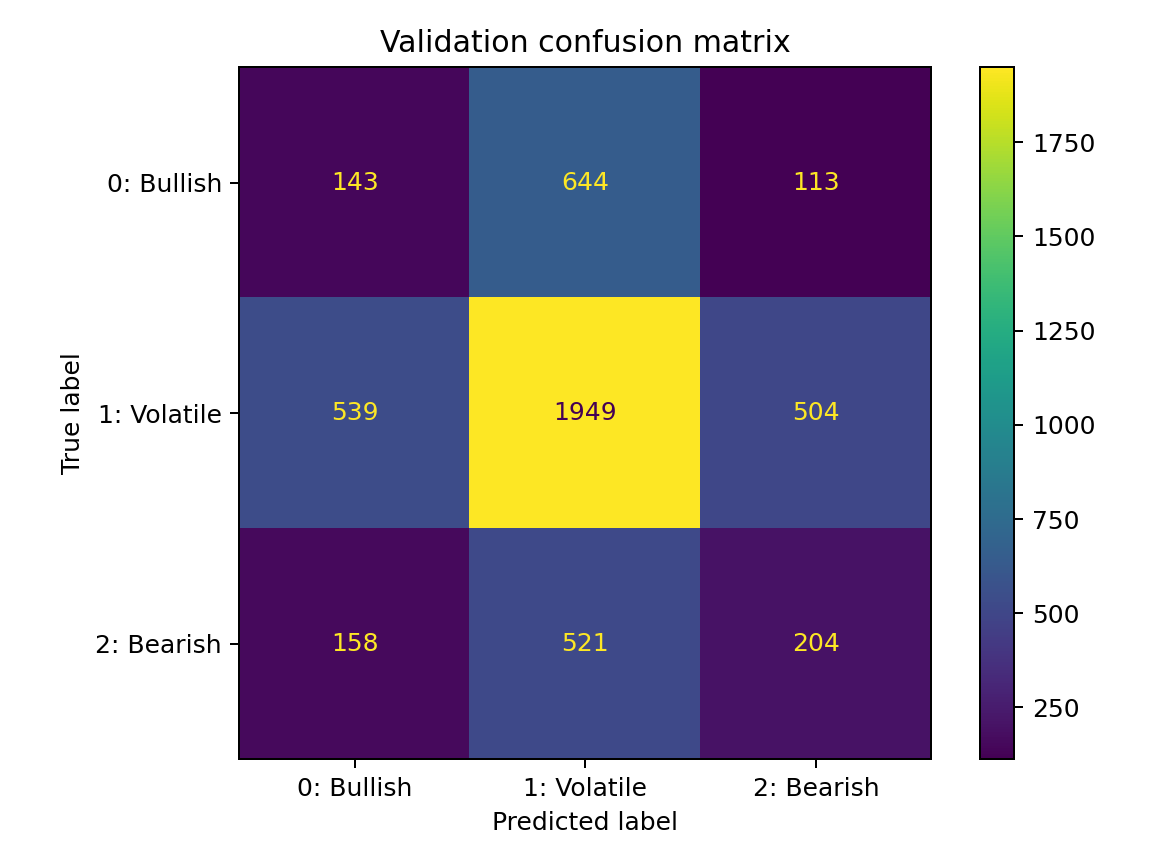

In [17]:
from IPython.display import display, Image

display(
    Image(
        filename=str(
            logistic_dir / "validation_confusion_matrix.png"
        )
    )
)

In [18]:
!python -u "{SCRIPTS / 'train_embedding_model.py'}" \
    --model embedding_mlp

embedding_mlp epoch 01/40 | train loss=1.0367 macro-F1=0.3678 | val loss=1.0781 macro-F1=0.3118
embedding_mlp epoch 02/40 | train loss=1.0261 macro-F1=0.4177 | val loss=1.0807 macro-F1=0.3366
embedding_mlp epoch 03/40 | train loss=1.0165 macro-F1=0.4435 | val loss=1.0804 macro-F1=0.3185
embedding_mlp epoch 04/40 | train loss=1.0085 macro-F1=0.4656 | val loss=1.0807 macro-F1=0.3181
embedding_mlp epoch 05/40 | train loss=1.0005 macro-F1=0.4832 | val loss=1.0759 macro-F1=0.3250
embedding_mlp epoch 06/40 | train loss=0.9897 macro-F1=0.5070 | val loss=1.0791 macro-F1=0.3201
embedding_mlp epoch 07/40 | train loss=0.9838 macro-F1=0.5206 | val loss=1.0817 macro-F1=0.3274
embedding_mlp epoch 08/40 | train loss=0.9785 macro-F1=0.5350 | val loss=1.0862 macro-F1=0.3349
embedding_mlp epoch 09/40 | train loss=0.9729 macro-F1=0.5470 | val loss=1.0858 macro-F1=0.3341
Early stopping after epoch 9.
Completed embedding_mlp. Test has not been evaluated. Outputs: /kaggle/working/k3_soft_three_model_results

In [19]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

mlp_dir = RESULTS_ROOT / "embedding_mlp"

paths = {
    "best_model": mlp_dir / "best_model.pt",
    "last_checkpoint": mlp_dir / "last_checkpoint.pt",
    "training_history": mlp_dir / "training_history.csv",
    "training_report": mlp_dir / "training_report.json",
    "validation_predictions": mlp_dir / "validation_predictions.csv",
    "validation_confusion_matrix": (
        mlp_dir / "validation_confusion_matrix.png"
    ),
}

print("=" * 80)
print("EMBEDDING MLP FILE AUDIT")
print("=" * 80)

for name, path in paths.items():
    print(f"{name}: {path.is_file()} — {path}")

missing = [
    name
    for name, path in paths.items()
    if not path.is_file()
]

if missing:
    raise FileNotFoundError(f"Missing MLP outputs: {missing}")

history = pd.read_csv(paths["training_history"])

with paths["training_report"].open("r", encoding="utf-8") as handle:
    report = json.load(handle)

checkpoint = torch.load(
    paths["best_model"],
    map_location="cpu",
    weights_only=False,
)

predictions = pd.read_csv(paths["validation_predictions"])

best_history_row = history.loc[
    history["validation_macro_f1"].idxmax()
]

print("\n" + "=" * 80)
print("CHECKPOINT CONTRACT")
print("=" * 80)

print("Model name:", checkpoint.get("model_name"))
print("Target kind:", checkpoint.get("target_kind"))
print("Number of classes:", checkpoint.get("num_classes"))
print("Best epoch:", checkpoint.get("best_epoch"))
print(
    "Best checkpoint validation macro-F1:",
    checkpoint.get("best_validation_macro_f1"),
)

print("\n" + "=" * 80)
print("TRAINING HISTORY")
print("=" * 80)

display(history)

print("\nBest history row:")
print(best_history_row.to_string())

print("\n" + "=" * 80)
print("VALIDATION REPORT")
print("=" * 80)

validation = report["validation"]

print("Model:", report["model"])
print("Best epoch:", report["best_epoch"])
print(
    "Best validation macro-F1:",
    report["best_validation_macro_f1"],
)
print("Validation accuracy:", validation["accuracy"])
print(
    "Validation balanced accuracy:",
    validation["balanced_accuracy"],
)
print("Validation macro-F1:", validation["macro_f1"])
print("Validation weighted-F1:", validation["weighted_f1"])
print(
    "Validation soft Brier score:",
    validation["soft_brier_score"],
)
print("Validation loss:", validation["loss"])
print("Elapsed seconds:", report["elapsed_seconds"])
print("Test evaluated:", report["test_evaluated"])
print(
    "Standardizer fitted on training only:",
    report["standardizer_fitted_on_training_only"],
)
print("Soft class weights:", report["soft_class_weights"])

print("\nPer-class validation metrics:")

for cluster_id in ["0", "1", "2"]:
    metrics = validation["per_class"][cluster_id]

    print(
        f"Cluster {cluster_id} — {metrics['regime_name']}: "
        f"precision={metrics['precision']:.6f}, "
        f"recall={metrics['recall']:.6f}, "
        f"F1={metrics['f1']:.6f}, "
        f"support={metrics['support']}"
    )

confusion = np.asarray(validation["confusion_matrix"])

print("\nConfusion matrix:")
print(confusion)

print("\nPrediction distribution:")

for cluster_id in range(3):
    count = int(
        (
            predictions["predicted_target_cluster_id"]
            == cluster_id
        ).sum()
    )

    percentage = 100.0 * count / len(predictions)

    print(
        f"Cluster {cluster_id}: "
        f"{count:,}/{len(predictions):,} "
        f"({percentage:.2f}%)"
    )

probability_columns = [
    "predicted_probability_cluster_0",
    "predicted_probability_cluster_1",
    "predicted_probability_cluster_2",
]

probabilities = predictions[probability_columns].to_numpy(
    dtype=float
)

print("\nValidation prediction rows:", len(predictions))
print(
    "Predicted classes:",
    sorted(
        predictions[
            "predicted_target_cluster_id"
        ].unique().tolist()
    ),
)
print(
    "Probabilities finite:",
    np.isfinite(probabilities).all(),
)
print(
    "Probability rows sum to 1:",
    np.allclose(
        probabilities.sum(axis=1),
        1.0,
        atol=1e-5,
    ),
)

assert checkpoint["model_name"] == "embedding_mlp"
assert checkpoint["target_kind"] == "k3_soft_membership_v1"
assert checkpoint["num_classes"] == 3
assert report["model"] == "embedding_mlp"
assert report["test_evaluated"] is False
assert report["standardizer_fitted_on_training_only"] is True
assert report["best_epoch"] == checkpoint["best_epoch"]
assert np.isclose(
    report["best_validation_macro_f1"],
    checkpoint["best_validation_macro_f1"],
)
assert np.isclose(
    report["best_validation_macro_f1"],
    best_history_row["validation_macro_f1"],
)
assert len(predictions) == 4775
assert np.isfinite(probabilities).all()
assert np.allclose(
    probabilities.sum(axis=1),
    1.0,
    atol=1e-5,
)

test_embedding_path = (
    RESULTS_ROOT
    / "frozen_resnet18_embeddings"
    / "test_embeddings.npz"
)

assert not test_embedding_path.exists()

print("\nEMBEDDING MLP AUDIT PASSED")
print("The validation-best MLP checkpoint is valid.")
print("The independent test remains unevaluated.")

EMBEDDING MLP FILE AUDIT
best_model: True — /kaggle/working/k3_soft_three_model_results_v1_3/embedding_mlp/best_model.pt
last_checkpoint: True — /kaggle/working/k3_soft_three_model_results_v1_3/embedding_mlp/last_checkpoint.pt
training_history: True — /kaggle/working/k3_soft_three_model_results_v1_3/embedding_mlp/training_history.csv
training_report: True — /kaggle/working/k3_soft_three_model_results_v1_3/embedding_mlp/training_report.json
validation_predictions: True — /kaggle/working/k3_soft_three_model_results_v1_3/embedding_mlp/validation_predictions.csv
validation_confusion_matrix: True — /kaggle/working/k3_soft_three_model_results_v1_3/embedding_mlp/validation_confusion_matrix.png

CHECKPOINT CONTRACT
Model name: embedding_mlp
Target kind: k3_soft_membership_v1
Number of classes: 3
Best epoch: 2
Best checkpoint validation macro-F1: 0.3366360230941579

TRAINING HISTORY


,epoch,learning_rate,train_loss,train_macro_f1,validation_loss,validation_macro_f1,validation_balanced_accuracy,validation_soft_brier_score
0,1,0.00100,1.036702,0.367758,1.078128,0.311758,0.325078,0.135707
1,2,0.00100,1.026113,0.417677,1.080695,0.336636,0.337935,0.137396
2,3,0.00100,1.016503,0.443512,1.080370,0.318479,0.324703,0.137237
3,4,0.00100,1.008484,0.465564,1.080682,0.318053,0.324121,0.137158
4,5,0.00050,1.000478,0.483223,1.075935,0.324997,0.331320,0.134035
5,6,0.00050,0.989705,0.507016,1.079123,0.320074,0.327379,0.136136
6,7,0.00050,0.983780,0.520630,1.081709,0.327427,0.332375,0.137723
7,8,0.00025,0.978455,0.534971,1.086196,0.334917,0.336747,0.140541
8,9,0.00025,0.972912,0.547041,1.085772,0.334061,0.336166,0.140293



Best history row:
epoch                           2.000000
learning_rate                   0.001000
train_loss                      1.026113
train_macro_f1                  0.417677
validation_loss                 1.080695
validation_macro_f1             0.336636
validation_balanced_accuracy    0.337935
validation_soft_brier_score     0.137396

VALIDATION REPORT
Model: embedding_mlp
Best epoch: 2
Best validation macro-F1: 0.3366360230941579
Validation accuracy: 0.4938219895287958
Validation balanced accuracy: 0.33793539115086646
Validation macro-F1: 0.3366360230941579
Validation weighted-F1: 0.47814910552931944
Validation soft Brier score: 0.13739606834341067
Validation loss: 1.0806950276809213
Elapsed seconds: 12.547386646270752
Test evaluated: False
Standardizer fitted on training only: True
Soft class weights: [1.3222295045852661, 0.6522430777549744, 1.4073984622955322]

Per-class validation metrics:
Cluster 0 — Bullish: precision=0.184241, recall=0.176667, F1=0.180374, support=900

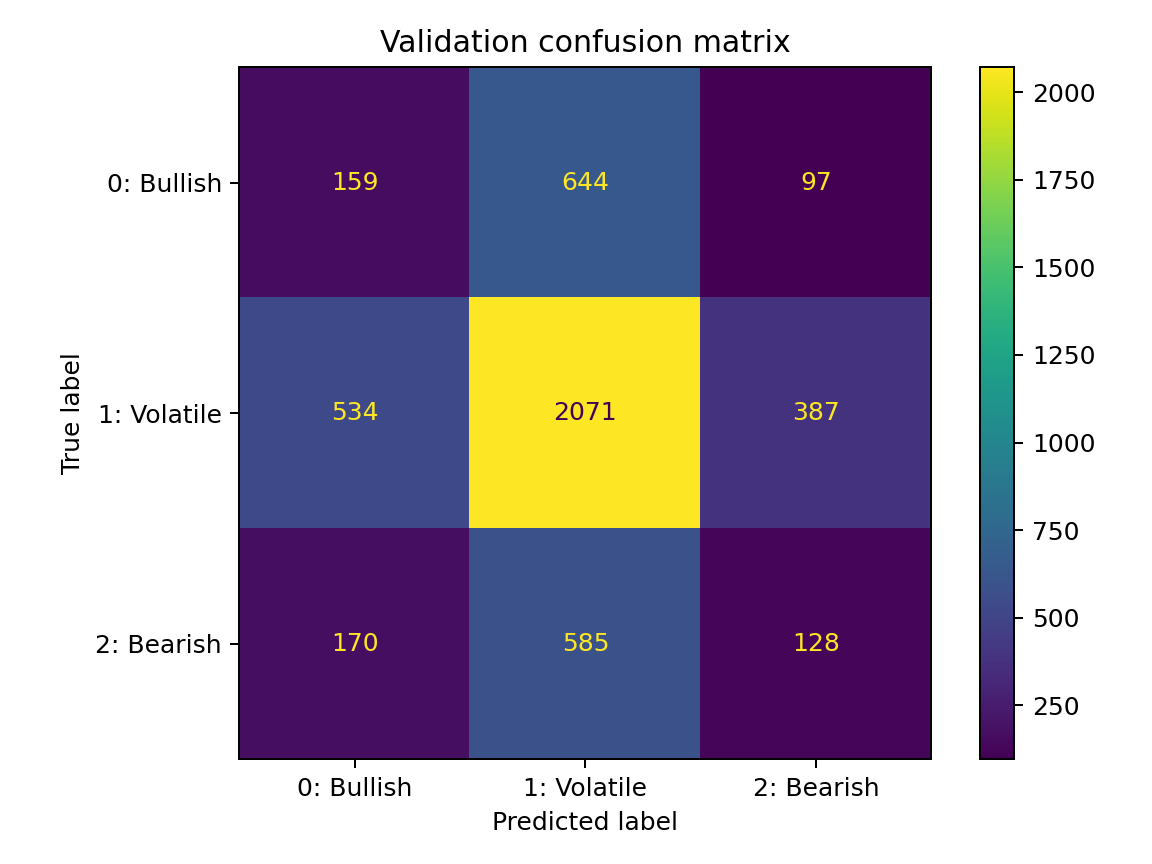

In [20]:
from IPython.display import display, Image

display(
    Image(
        filename=str(
            mlp_dir / "validation_confusion_matrix.png"
        )
    )
)

In [22]:
from pathlib import Path

layer4_dir = (
    RESULTS_ROOT / "soft_membership_unfreeze_layer4"
)

test_embedding_path = (
    RESULTS_ROOT
    / "frozen_resnet18_embeddings"
    / "test_embeddings.npz"
)

test_complete_lock = (
    RESULTS_ROOT / "TEST_EVALUATION_COMPLETE.json"
)

test_progress_lock = (
    RESULTS_ROOT / "TEST_EVALUATION_IN_PROGRESS.json"
)

print("Layer-4 output directory:", layer4_dir)
print("Test embeddings exist:", test_embedding_path.exists())
print("Test-complete lock exists:", test_complete_lock.exists())
print("Test-progress lock exists:", test_progress_lock.exists())

assert not test_embedding_path.exists()
assert not test_complete_lock.exists()
assert not test_progress_lock.exists()

print("\nLAYER-4 TRAINING SAFETY CHECK PASSED")
print("The independent test remains untouched.")

Layer-4 output directory: /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4
Test embeddings exist: False
Test-complete lock exists: False
Test-progress lock exists: False

LAYER-4 TRAINING SAFETY CHECK PASSED
The independent test remains untouched.


In [23]:
!python -u "{SCRIPTS / 'train_classifier.py'}"

KAGGLE K=3 SOFT-MEMBERSHIP UNFREEZE_LAYER4 CLASSIFIER
Device: cuda
Training rows: 42,100
Validation rows: 4,775
Test rows held out: 9,301
Trainable parameters: 8,395,267
Total parameters: 11,178,051
AMP enabled: True
Soft class-mass weights: [1.32223, 0.65224, 1.4074]
Epoch 01/20 training (resume batch 0): 100%|█| 2632/2632 [02:32<00:00, 17.30batc
Epoch 01/20 validation: 100%|██████████████| 150/150 [00:15<00:00,  9.62batch/s]
Epoch 01/20 | train loss=1.0291 macro-F1=0.4364 | val loss=1.1093 macro-F1=0.3103 balanced-acc=0.3101
Epoch 02/20 training (resume batch 0): 100%|█| 2632/2632 [02:16<00:00, 19.33batc
Epoch 02/20 validation: 100%|██████████████| 150/150 [00:13<00:00, 11.16batch/s]
Epoch 02/20 | train loss=0.9521 macro-F1=0.6164 | val loss=1.1143 macro-F1=0.3392 balanced-acc=0.3395
Epoch 03/20 training (resume batch 0): 100%|█| 2632/2632 [02:10<00:00, 20.16batc
Epoch 03/20 validation: 100%|██████████████| 150/150 [00:13<00:00, 11.03batch/s]
Epoch 03/20 | train loss=0.9037 macro-F1=

In [26]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

layer4_dir = (
    RESULTS_ROOT / "soft_membership_unfreeze_layer4"
)

paths = {
    "best_model": layer4_dir / "best_model.pt",
    "last_checkpoint": layer4_dir / "last_checkpoint.pt",
    "training_progress": layer4_dir / "training_progress.json",
    "training_history": layer4_dir / "training_history.csv",
    "training_report": layer4_dir / "training_report.json",
    "validation_predictions": layer4_dir / "validation_predictions.csv",
    "validation_confusion_matrix": (
        layer4_dir / "validation_confusion_matrix.png"
    ),
    "loss_curve": layer4_dir / "loss_curve.png",
    "macro_f1_curve": layer4_dir / "macro_f1_curve.png",
}

print("=" * 80)
print("LAYER-4 RESNET18 FILE AUDIT")
print("=" * 80)

for name, path in paths.items():
    print(f"{name}: {path.is_file()} — {path}")

missing = [
    name
    for name, path in paths.items()
    if not path.is_file()
]

if missing:
    raise FileNotFoundError(
        f"Missing Layer-4 outputs: {missing}"
    )

history = pd.read_csv(paths["training_history"])

with paths["training_report"].open(
    "r",
    encoding="utf-8",
) as handle:
    report = json.load(handle)

with paths["training_progress"].open(
    "r",
    encoding="utf-8",
) as handle:
    progress = json.load(handle)

checkpoint = torch.load(
    paths["best_model"],
    map_location="cpu",
    weights_only=False,
)

last_checkpoint = torch.load(
    paths["last_checkpoint"],
    map_location="cpu",
    weights_only=False,
)

predictions = pd.read_csv(
    paths["validation_predictions"]
)

print("\n" + "=" * 80)
print("CHECKPOINT CONTRACT")
print("=" * 80)

print(
    "Training mode:",
    checkpoint.get("training_mode"),
)
print(
    "Target kind:",
    checkpoint.get("target_kind"),
)
print(
    "Number of classes:",
    checkpoint.get("num_classes"),
)
print(
    "Best epoch in checkpoint:",
    checkpoint.get("best_epoch"),
)
print(
    "Best validation macro-F1 in checkpoint:",
    checkpoint.get("best_validation_macro_f1"),
)
print(
    "Last completed checkpoint epoch:",
    last_checkpoint.get("epoch"),
)
print(
    "Last completed progress epoch:",
    progress.get("last_completed_epoch"),
)

print("\n" + "=" * 80)
print("TRAINING HISTORY")
print("=" * 80)

display(history)

expected_epochs = list(
    range(1, int(history["epoch"].max()) + 1)
)

recorded_epochs = history["epoch"].astype(int).tolist()

print("Recorded epochs:", recorded_epochs)
print("Expected epochs:", expected_epochs)
print(
    "Epoch sequence complete:",
    recorded_epochs == expected_epochs,
)

best_history_row = history.loc[
    history["validation_macro_f1"].idxmax()
]

print("\nBest history row:")
print(best_history_row.to_string())

print("\n" + "=" * 80)
print("VALIDATION REPORT")
print("=" * 80)

validation = report["validation"]

print(
    "Training mode:",
    report["training_mode"],
)
print(
    "Target kind:",
    report["target_kind"],
)
print(
    "Number of classes:",
    report["num_classes"],
)
print(
    "Best epoch:",
    report["best_epoch"],
)
print(
    "Best validation macro-F1:",
    report["best_validation_macro_f1"],
)
print(
    "Validation accuracy:",
    validation["accuracy"],
)
print(
    "Validation balanced accuracy:",
    validation["balanced_accuracy"],
)
print(
    "Validation macro-F1:",
    validation["macro_f1"],
)
print(
    "Validation weighted-F1:",
    validation["weighted_f1"],
)
print(
    "Validation soft cross-entropy:",
    validation["soft_cross_entropy"],
)
print(
    "Validation soft Brier score:",
    validation["soft_brier_score"],
)
print(
    "Elapsed seconds:",
    report["elapsed_seconds"],
)
print(
    "Trainable parameters:",
    report["trainable_parameters"],
)
print(
    "Total parameters:",
    report["total_parameters"],
)
print(
    "Soft class weights:",
    report["soft_class_weights"],
)
print(
    "Test evaluated:",
    report["test_evaluated"],
)

print("\nPer-class validation metrics:")

for cluster_id in ["0", "1", "2"]:
    metrics = validation["per_class"][cluster_id]

    print(
        f"Cluster {cluster_id} — {metrics['regime_name']}: "
        f"precision={metrics['precision']:.6f}, "
        f"recall={metrics['recall']:.6f}, "
        f"F1={metrics['f1']:.6f}, "
        f"support={metrics['support']}"
    )

confusion = np.asarray(
    validation["confusion_matrix"]
)

print("\nConfusion matrix:")
print(confusion)

print("\nPrediction distribution:")

for cluster_id in range(3):
    count = int(
        (
            predictions["predicted_target_cluster_id"]
            == cluster_id
        ).sum()
    )

    percentage = 100.0 * count / len(predictions)

    print(
        f"Cluster {cluster_id}: "
        f"{count:,}/{len(predictions):,} "
        f"({percentage:.2f}%)"
    )

probability_columns = [
    "probability_cluster_0",
    "probability_cluster_1",
    "probability_cluster_2",
]

probabilities = predictions[
    probability_columns
].to_numpy(dtype=float)

print(
    "\nValidation prediction rows:",
    len(predictions),
)
print(
    "Predicted classes:",
    sorted(
        predictions[
            "predicted_target_cluster_id"
        ].unique().tolist()
    ),
)
print(
    "Probabilities finite:",
    np.isfinite(probabilities).all(),
)
print(
    "Probability rows sum to 1:",
    np.allclose(
        probabilities.sum(axis=1),
        1.0,
        atol=1e-5,
    ),
)

test_embedding_path = (
    RESULTS_ROOT
    / "frozen_resnet18_embeddings"
    / "test_embeddings.npz"
)

test_complete_lock = (
    RESULTS_ROOT
    / "TEST_EVALUATION_COMPLETE.json"
)

test_progress_lock = (
    RESULTS_ROOT
    / "TEST_EVALUATION_IN_PROGRESS.json"
)

print("\n" + "=" * 80)
print("TEST-ISOLATION CHECK")
print("=" * 80)

print(
    "Test embeddings exist:",
    test_embedding_path.exists(),
)
print(
    "Test-complete lock exists:",
    test_complete_lock.exists(),
)
print(
    "Test-progress lock exists:",
    test_progress_lock.exists(),
)

assert checkpoint["training_mode"] == "unfreeze_layer4"
assert checkpoint["target_kind"] == "k3_soft_membership_v1"
assert checkpoint["num_classes"] == 3

assert report["training_mode"] == "unfreeze_layer4"
assert report["target_kind"] == "k3_soft_membership_v1"
assert report["num_classes"] == 3
assert report["test_evaluated"] is False

assert report["best_epoch"] == checkpoint["best_epoch"]
assert np.isclose(
    report["best_validation_macro_f1"],
    checkpoint["best_validation_macro_f1"],
)
assert np.isclose(
    report["best_validation_macro_f1"],
    best_history_row["validation_macro_f1"],
)

assert recorded_epochs == expected_epochs
assert int(history["epoch"].max()) == 17
assert 15 in recorded_epochs

assert report["trainable_parameters"] == 8395267
assert report["total_parameters"] == 11178051

assert len(predictions) == 4775
assert np.isfinite(probabilities).all()
assert np.allclose(
    probabilities.sum(axis=1),
    1.0,
    atol=1e-5,
)

assert not test_embedding_path.exists()
assert not test_complete_lock.exists()
assert not test_progress_lock.exists()

print("\nLAYER-4 RESNET18 AUDIT PASSED")
print("The validation-best Layer-4 checkpoint is valid.")
print("The independent test remains unevaluated.")

LAYER-4 RESNET18 FILE AUDIT
best_model: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4/best_model.pt
last_checkpoint: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4/last_checkpoint.pt
training_progress: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4/training_progress.json
training_history: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4/training_history.csv
training_report: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4/training_report.json
validation_predictions: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4/validation_predictions.csv
validation_confusion_matrix: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4/validation_confusion_matrix.png
loss_curve: True — /kaggle/working/k3_soft_three_model_results_

,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,train_balanced_accuracy,validation_loss,validation_soft_brier_score,validation_accuracy,validation_macro_f1,validation_balanced_accuracy
0,1,0.000100,1.029128,0.551710,0.436354,0.442412,1.109324,0.156323,0.436230,0.310290,0.310118
1,2,0.000100,0.952079,0.674822,0.616422,0.656873,1.114340,0.156874,0.485236,0.339235,0.339531
2,3,0.000100,0.903730,0.752257,0.714433,0.776027,1.148476,0.177858,0.416126,0.345259,0.361902
3,4,0.000100,0.883034,0.781876,0.753128,0.828221,1.115669,0.157436,0.471204,0.349108,0.350075
4,5,0.000100,0.872761,0.792328,0.767984,0.850902,1.139029,0.173078,0.401466,0.339965,0.352578
5,6,0.000100,0.865729,0.798480,0.776166,0.864230,1.108506,0.153711,0.479581,0.337002,0.341561
6,7,0.000050,0.861668,0.799929,0.779694,0.871850,1.117909,0.159632,0.440209,0.347517,0.350951
7,8,0.000050,0.852935,0.801663,0.784081,0.882840,1.108383,0.153825,0.459058,0.352486,0.355003
8,9,0.000050,0.849133,0.801021,0.784947,0.886429,1.121764,0.162758,0.416754,0.344630,0.355401
9,10,0.000050,0.847876,0.803349,0.787400,0.888515,1.105402,0.151632,0.466597,0.352433,0.354808


Recorded epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Expected epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Epoch sequence complete: True

Best history row:
epoch                           12.000000
learning_rate                    0.000025
train_loss                       0.844589
train_accuracy                   0.801116
train_macro_f1                   0.786387
train_balanced_accuracy          0.890069
validation_loss                  1.107342
validation_soft_brier_score      0.153424
validation_accuracy              0.453403
validation_macro_f1              0.353461
validation_balanced_accuracy     0.355905

VALIDATION REPORT
Training mode: unfreeze_layer4
Target kind: k3_soft_membership_v1
Number of classes: 3
Best epoch: 12
Best validation macro-F1: 0.35346146825407354
Validation accuracy: 0.45340314136125653
Validation balanced accuracy: 0.3559054246863187
Validation macro-F1: 0.35346146825407354
Validation weighted-F1: 0.46456089577

AssertionError: 

validation_confusion_matrix.png


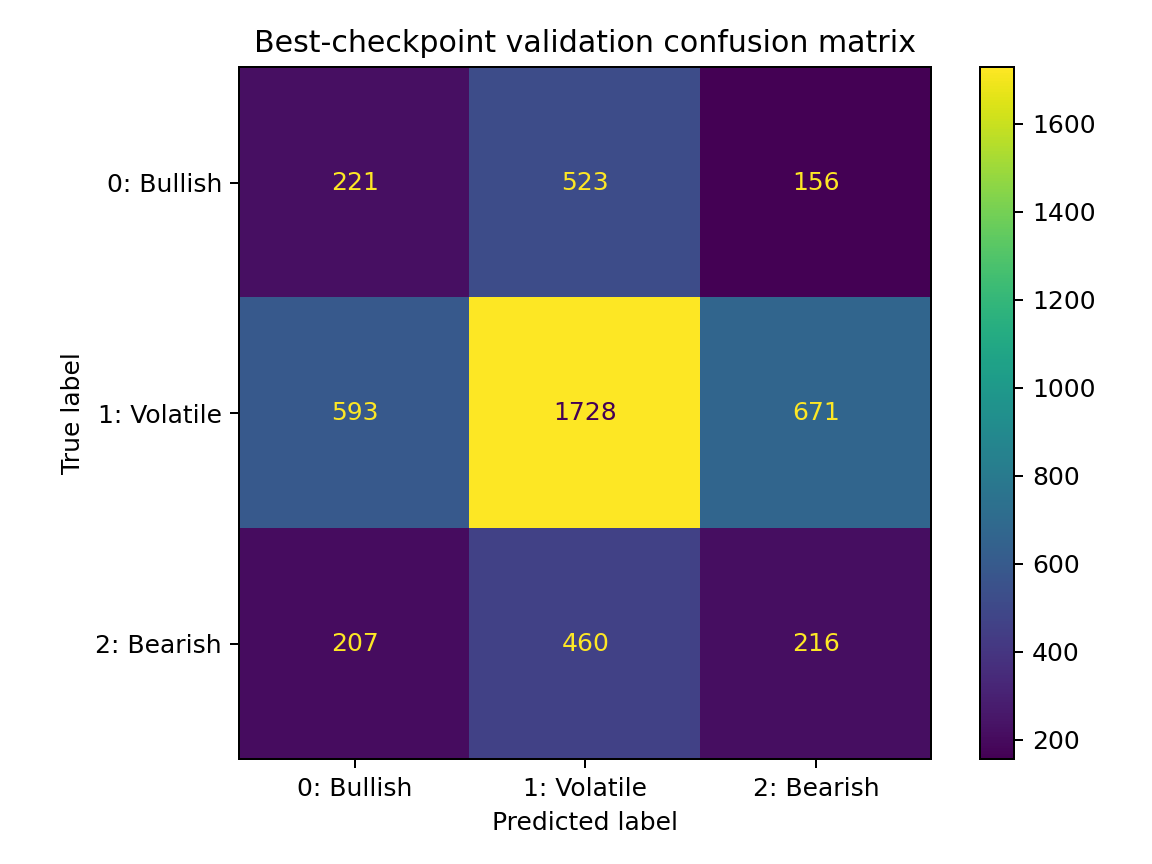

loss_curve.png


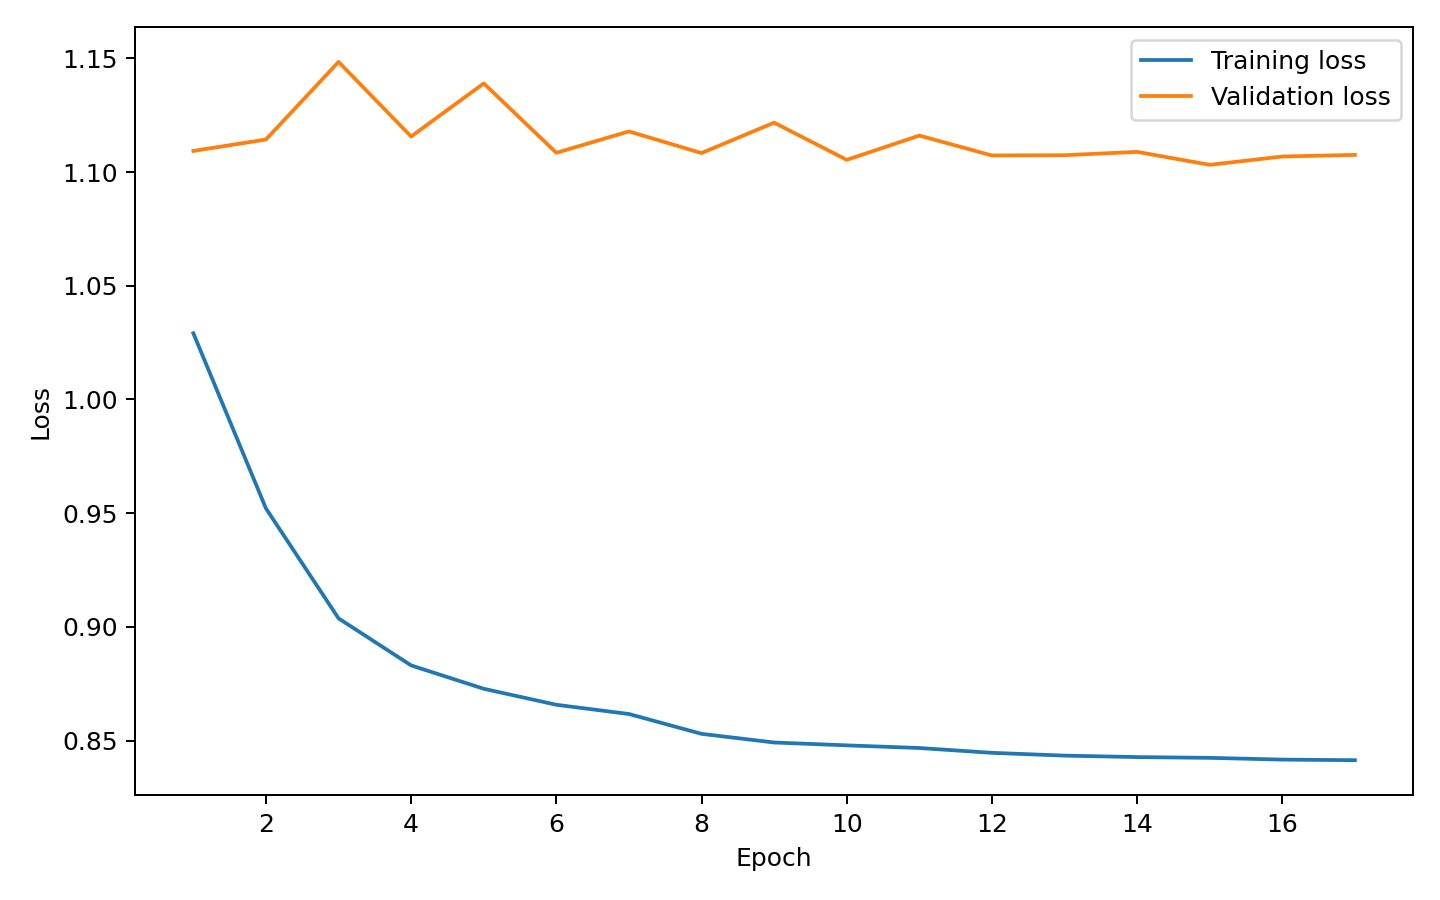

macro_f1_curve.png


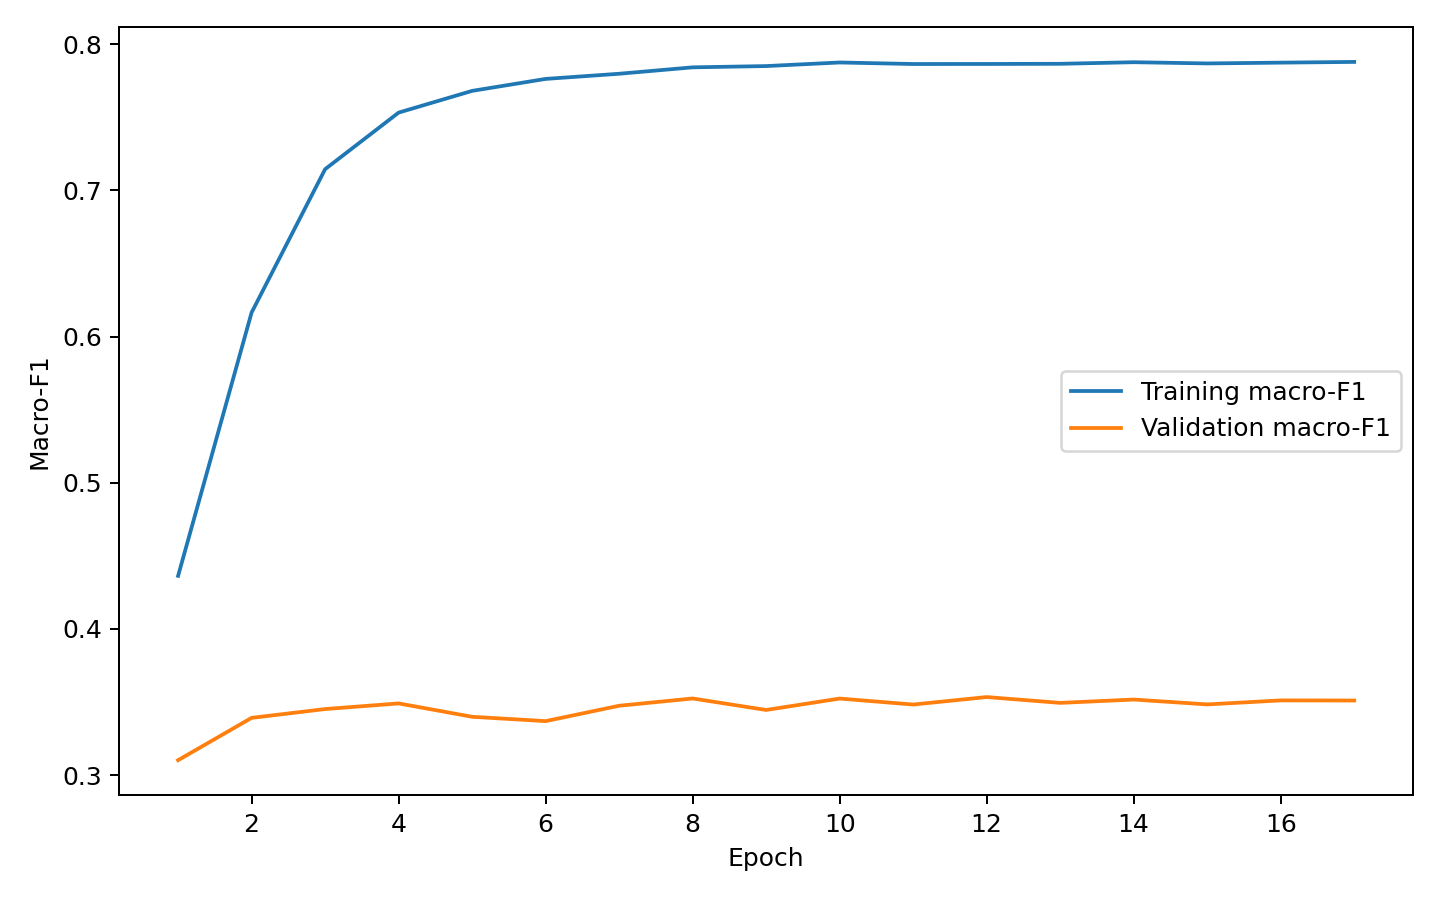

In [27]:
from IPython.display import display, Image

plot_paths = [
    layer4_dir / "validation_confusion_matrix.png",
    layer4_dir / "loss_curve.png",
    layer4_dir / "macro_f1_curve.png",
]

for path in plot_paths:
    print(path.name)
    display(Image(filename=str(path)))

In [28]:
import numpy as np
import pandas as pd

prediction_path = (
    RESULTS_ROOT
    / "soft_membership_unfreeze_layer4"
    / "validation_predictions.csv"
)

predictions = pd.read_csv(prediction_path)

probability_columns = [
    "probability_cluster_0",
    "probability_cluster_1",
    "probability_cluster_2",
]

probabilities = predictions[
    probability_columns
].to_numpy(dtype=np.float64)

row_sums = probabilities.sum(axis=1)
absolute_deviation = np.abs(row_sums - 1.0)

print("=" * 80)
print("LAYER-4 PROBABILITY PRECISION DIAGNOSTIC")
print("=" * 80)

print("Rows:", len(probabilities))
print("Probabilities finite:", np.isfinite(probabilities).all())
print("Minimum probability:", probabilities.min())
print("Maximum probability:", probabilities.max())

print("\nRow-sum statistics:")
print("Minimum row sum:", row_sums.min())
print("Maximum row sum:", row_sums.max())
print("Mean row sum:", row_sums.mean())
print(
    "Maximum absolute deviation from 1:",
    absolute_deviation.max(),
)
print(
    "Mean absolute deviation from 1:",
    absolute_deviation.mean(),
)

for tolerance in [1e-5, 1e-4, 5e-4, 1e-3]:
    failing = int((absolute_deviation > tolerance).sum())

    print(
        f"Rows exceeding {tolerance}: "
        f"{failing:,}/{len(row_sums):,}"
    )

worst_indices = np.argsort(
    absolute_deviation
)[-10:][::-1]

worst_rows = pd.DataFrame({
    "row_index": worst_indices,
    "probability_0": probabilities[worst_indices, 0],
    "probability_1": probabilities[worst_indices, 1],
    "probability_2": probabilities[worst_indices, 2],
    "row_sum": row_sums[worst_indices],
    "absolute_deviation": absolute_deviation[worst_indices],
})

print("\nTen greatest deviations:")
display(worst_rows)

negative_count = int((probabilities < 0).sum())
above_one_count = int((probabilities > 1).sum())

print("\nNegative probability values:", negative_count)
print("Probability values above 1:", above_one_count)

predicted_from_probabilities = probabilities.argmax(axis=1)
saved_predictions = predictions[
    "predicted_target_cluster_id"
].to_numpy(dtype=int)

print(
    "Argmax agrees with saved predictions:",
    np.array_equal(
        predicted_from_probabilities,
        saved_predictions,
    ),
)

if (
    np.isfinite(probabilities).all()
    and negative_count == 0
    and above_one_count == 0
    and absolute_deviation.max() <= 1e-3
    and np.array_equal(
        predicted_from_probabilities,
        saved_predictions,
    )
):
    print(
        "\nDIAGNOSIS: consistent with float16 probability rounding."
    )
else:
    print(
        "\nDIAGNOSIS: deviation is larger than expected; "
        "do not proceed."
    )

LAYER-4 PROBABILITY PRECISION DIAGNOSTIC
Rows: 4775
Probabilities finite: True
Minimum probability: 0.05889892578125
Maximum probability: 0.712890625

Row-sum statistics:
Minimum row sum: 0.9996337890625
Maximum row sum: 1.0003662109375
Mean row sum: 1.0000016361256545
Maximum absolute deviation from 1: 0.0003662109375
Mean absolute deviation from 1: 8.201079842931937e-05
Rows exceeding 1e-05: 2,316/4,775
Rows exceeding 0.0001: 2,306/4,775
Rows exceeding 0.0005: 0/4,775
Rows exceeding 0.001: 0/4,775

Ten greatest deviations:


,row_index,probability_0,probability_1,probability_2,row_sum,absolute_deviation
0,1950,0.190552,0.529785,0.280029,1.000366,0.000366
1,4278,0.182983,0.553711,0.262939,0.999634,0.000366
2,442,0.579590,0.149536,0.271240,1.000366,0.000366
3,3373,0.276855,0.509766,0.213745,1.000366,0.000366
4,2676,0.177368,0.537598,0.285400,1.000366,0.000366
5,889,0.538086,0.264893,0.196655,0.999634,0.000366
6,3620,0.273438,0.545898,0.181030,1.000366,0.000366
7,2527,0.292480,0.190552,0.516602,0.999634,0.000366
8,4086,0.286377,0.522461,0.190796,0.999634,0.000366
9,1778,0.525391,0.285645,0.188599,0.999634,0.000366



Negative probability values: 0
Probability values above 1: 0
Argmax agrees with saved predictions: False

DIAGNOSIS: deviation is larger than expected; do not proceed.


In [32]:
from pathlib import Path

matches = list(
    Path("/kaggle/input").rglob(
        "reevaluate_layer4_validation.py"
    )
)

print("Matches found:", len(matches))

for match in matches:
    print(match)

Matches found: 1
/kaggle/input/datasets/mozimandias/k3-soft-membership-three-model-trainer-v1-4/k3_soft_membership_kaggle_three_model_v1_4/soft_supervised/reevaluate_layer4_validation.py


In [34]:
from pathlib import Path

V13_PACKAGE = Path(
    "/kaggle/working/"
    "k3_soft_membership_kaggle_three_model_v1_3"
)

V13_SCRIPTS = V13_PACKAGE / "soft_supervised"

V13_RESULTS = Path(
    "/kaggle/working/"
    "k3_soft_three_model_results_v1_3"
)

required_files = {
    "v1.3 configuration": (
        V13_PACKAGE
        / "configs"
        / "training_config.json"
    ),
    "Logistic Regression checkpoint": (
        V13_RESULTS
        / "soft_logistic_regression"
        / "best_model.pt"
    ),
    "MLP checkpoint": (
        V13_RESULTS
        / "embedding_mlp"
        / "best_model.pt"
    ),
    "Layer-4 checkpoint": (
        V13_RESULTS
        / "soft_membership_unfreeze_layer4"
        / "best_model.pt"
    ),
    "Layer-4 training history": (
        V13_RESULTS
        / "soft_membership_unfreeze_layer4"
        / "training_history.csv"
    ),
    "Layer-4 training report": (
        V13_RESULTS
        / "soft_membership_unfreeze_layer4"
        / "training_report.json"
    ),
}

print("=" * 80)
print("EXISTING v1.3 RESULTS CHECK")
print("=" * 80)

for name, path in required_files.items():
    print(f"{name}: {path.is_file()} — {path}")

missing = [
    name
    for name, path in required_files.items()
    if not path.is_file()
]

if missing:
    raise FileNotFoundError(
        f"Missing existing experiment files: {missing}"
    )

print("\nEXISTING v1.3 RESULTS ARE INTACT")
print("No retraining is required.")

EXISTING v1.3 RESULTS CHECK
v1.3 configuration: True — /kaggle/working/k3_soft_membership_kaggle_three_model_v1_3/configs/training_config.json
Logistic Regression checkpoint: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_logistic_regression/best_model.pt
MLP checkpoint: True — /kaggle/working/k3_soft_three_model_results_v1_3/embedding_mlp/best_model.pt
Layer-4 checkpoint: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4/best_model.pt
Layer-4 training history: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4/training_history.csv
Layer-4 training report: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4/training_report.json

EXISTING v1.3 RESULTS ARE INTACT
No retraining is required.


In [35]:
from pathlib import Path
import shutil

V14_SCRIPT = Path(
    "/kaggle/input/datasets/mozimandias/"
    "k3-soft-membership-three-model-trainer-v1-4/"
    "k3_soft_membership_kaggle_three_model_v1_4/"
    "soft_supervised/"
    "reevaluate_layer4_validation.py"
)

V14_SCRIPTS = V14_SCRIPT.parent

V13_SCRIPTS = Path(
    "/kaggle/working/"
    "k3_soft_membership_kaggle_three_model_v1_3/"
    "soft_supervised"
)

files_to_install = [
    "train_classifier.py",
    "evaluate_checkpoint.py",
    "reevaluate_layer4_validation.py",
]

print("=" * 80)
print("INSTALLING FLOAT32 INFERENCE CORRECTION")
print("=" * 80)

for filename in files_to_install:
    source = V14_SCRIPTS / filename
    destination = V13_SCRIPTS / filename

    if not source.is_file():
        raise FileNotFoundError(
            f"v1.4 source file is missing: {source}"
        )

    shutil.copy2(source, destination)

    print(
        f"{filename}: {destination.is_file()} "
        f"— {destination}"
    )

trainer_text = (
    V13_SCRIPTS / "train_classifier.py"
).read_text(encoding="utf-8")

test_evaluator_text = (
    V13_SCRIPTS / "evaluate_checkpoint.py"
).read_text(encoding="utf-8")

reevaluator_text = (
    V13_SCRIPTS / "reevaluate_layer4_validation.py"
).read_text(encoding="utf-8")

assert "logits_float = logits.float()" in trainer_text
assert (
    "torch.softmax(logits_float, dim=1)"
    in trainer_text
)

assert (
    "logits_float = logits.float()"
    in test_evaluator_text
)
assert (
    "torch.softmax(logits_float, dim=1)"
    in test_evaluator_text
)

assert (
    "validation_probability_dtype"
    in reevaluator_text
)

print("\nFLOAT32 INFERENCE CORRECTION INSTALLED")
print("Existing checkpoints and training history were not changed.")

INSTALLING FLOAT32 INFERENCE CORRECTION
train_classifier.py: True — /kaggle/working/k3_soft_membership_kaggle_three_model_v1_3/soft_supervised/train_classifier.py
evaluate_checkpoint.py: True — /kaggle/working/k3_soft_membership_kaggle_three_model_v1_3/soft_supervised/evaluate_checkpoint.py
reevaluate_layer4_validation.py: True — /kaggle/working/k3_soft_membership_kaggle_three_model_v1_3/soft_supervised/reevaluate_layer4_validation.py

FLOAT32 INFERENCE CORRECTION INSTALLED
Existing checkpoints and training history were not changed.


In [36]:
V13_SCRIPTS = Path(
    "/kaggle/working/"
    "k3_soft_membership_kaggle_three_model_v1_3/"
    "soft_supervised"
)

!python -u "{V13_SCRIPTS / 'reevaluate_layer4_validation.py'}"

Float32-probability validation reevaluation: 100%|█| 150/150 [00:13<00:00, 10.86
FLOAT32 VALIDATION REEVALUATION COMPLETE
Rows: 4,775
Best epoch: 12
Macro-F1: 0.3538085757
Balanced accuracy: 0.3562829256
Soft Brier score: 0.1534232377
Maximum probability-sum deviation: 1.04308128357e-07
Test evaluated: False
Outputs: /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4


In [37]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

layer4_dir = (
    RESULTS_ROOT
    / "soft_membership_unfreeze_layer4"
)

original_path = (
    layer4_dir
    / "validation_predictions_mixed_precision_original.csv"
)

corrected_path = (
    layer4_dir
    / "validation_predictions.csv"
)

original_report_path = (
    layer4_dir
    / "training_report_mixed_precision_probabilities_original.json"
)

corrected_report_path = (
    layer4_dir / "training_report.json"
)

original = pd.read_csv(original_path)
corrected = pd.read_csv(corrected_path)

with original_report_path.open(
    "r",
    encoding="utf-8",
) as handle:
    original_report = json.load(handle)

with corrected_report_path.open(
    "r",
    encoding="utf-8",
) as handle:
    corrected_report = json.load(handle)

print("=" * 80)
print("ORIGINAL VS FLOAT32 REEVALUATION")
print("=" * 80)

print("Original rows:", len(original))
print("Corrected rows:", len(corrected))

original_actual = original[
    "actual_target_cluster_id"
].to_numpy(dtype=int)

corrected_actual = corrected[
    "actual_target_cluster_id"
].to_numpy(dtype=int)

original_predicted = original[
    "predicted_target_cluster_id"
].to_numpy(dtype=int)

corrected_predicted = corrected[
    "predicted_target_cluster_id"
].to_numpy(dtype=int)

actual_targets_equal = np.array_equal(
    original_actual,
    corrected_actual,
)

changed_mask = (
    original_predicted != corrected_predicted
)

changed_indices = np.flatnonzero(changed_mask)
changed_count = int(changed_mask.sum())

print(
    "Actual targets identical:",
    actual_targets_equal,
)
print(
    "Changed hard predictions:",
    f"{changed_count:,}/{len(corrected):,}",
)
print(
    "Changed percentage:",
    f"{100 * changed_count / len(corrected):.6f}%",
)

transition_table = pd.crosstab(
    pd.Series(
        original_predicted[changed_mask],
        name="original_prediction",
    ),
    pd.Series(
        corrected_predicted[changed_mask],
        name="corrected_prediction",
    ),
    dropna=False,
)

print("\nChanged-prediction transitions:")
display(transition_table)

probability_columns = [
    "probability_cluster_0",
    "probability_cluster_1",
    "probability_cluster_2",
]

corrected_probabilities = corrected[
    probability_columns
].to_numpy(dtype=np.float64)

sorted_probabilities = np.sort(
    corrected_probabilities,
    axis=1,
)

corrected_top_two_margin = (
    sorted_probabilities[:, -1]
    - sorted_probabilities[:, -2]
)

if changed_count:
    changed_details = corrected.loc[
        changed_mask,
        [
            "pair_id",
            "actual_target_cluster_id",
            "predicted_target_cluster_id",
            *probability_columns,
        ],
    ].copy()

    changed_details.insert(
        2,
        "original_predicted_target_cluster_id",
        original_predicted[changed_mask],
    )

    changed_details["corrected_top_two_margin"] = (
        corrected_top_two_margin[changed_mask]
    )

    print("\nChanged rows:")
    display(
        changed_details.sort_values(
            "corrected_top_two_margin"
        )
    )

    print(
        "Maximum top-two margin among changed rows:",
        corrected_top_two_margin[
            changed_mask
        ].max(),
    )
else:
    print("\nNo hard predictions changed.")

old_metrics = original_report["validation"]
new_metrics = corrected_report["validation"]

print("\nMetric changes:")

for metric in [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "soft_brier_score",
]:
    old_value = old_metrics[metric]
    new_value = new_metrics[metric]

    print(
        f"{metric}: "
        f"original={old_value:.12f}, "
        f"corrected={new_value:.12f}, "
        f"difference={new_value-old_value:+.12f}"
    )

row_sums = corrected_probabilities.sum(axis=1)

print("\nCorrected probability checks:")
print(
    "Probabilities finite:",
    np.isfinite(corrected_probabilities).all(),
)
print(
    "Maximum row-sum deviation:",
    np.abs(row_sums - 1.0).max(),
)
print(
    "Argmax matches corrected saved predictions:",
    np.array_equal(
        corrected_probabilities.argmax(axis=1),
        corrected_predicted,
    ),
)

test_embedding_path = (
    RESULTS_ROOT
    / "frozen_resnet18_embeddings"
    / "test_embeddings.npz"
)

test_complete_lock = (
    RESULTS_ROOT
    / "TEST_EVALUATION_COMPLETE.json"
)

test_progress_lock = (
    RESULTS_ROOT
    / "TEST_EVALUATION_IN_PROGRESS.json"
)

print("\nTest isolation:")
print(
    "Test embeddings exist:",
    test_embedding_path.exists(),
)
print(
    "Test-complete lock exists:",
    test_complete_lock.exists(),
)
print(
    "Test-progress lock exists:",
    test_progress_lock.exists(),
)

assert len(original) == 4775
assert len(corrected) == 4775
assert actual_targets_equal
assert np.isfinite(corrected_probabilities).all()
assert np.allclose(
    row_sums,
    1.0,
    atol=1e-6,
)
assert np.array_equal(
    corrected_probabilities.argmax(axis=1),
    corrected_predicted,
)
assert not test_embedding_path.exists()
assert not test_complete_lock.exists()
assert not test_progress_lock.exists()

print("\nPREDICTION-COMPARISON DIAGNOSTIC PASSED")

ORIGINAL VS FLOAT32 REEVALUATION
Original rows: 4775
Corrected rows: 4775
Actual targets identical: True
Changed hard predictions: 1/4,775
Changed percentage: 0.020942%

Changed-prediction transitions:


corrected_prediction,2
original_prediction,
0,1



Changed rows:


,pair_id,actual_target_cluster_id,original_predicted_target_cluster_id,predicted_target_cluster_id,probability_cluster_0,probability_cluster_1,probability_cluster_2,corrected_top_two_margin
3451,train_validation__sample_46921_46950__to__samp...,2,0,2,0.357985,0.283812,0.358203,0.000219


Maximum top-two margin among changed rows: 0.00021857023239141293

Metric changes:
accuracy: original=0.453403141361, corrected=0.453612565445, difference=+0.000209424084
balanced_accuracy: original=0.355905424686, corrected=0.356282925630, difference=+0.000377500944
macro_f1: original=0.353461468254, corrected=0.353808575726, difference=+0.000347107472
weighted_f1: original=0.464560895777, corrected=0.464753885292, difference=+0.000192989515
soft_brier_score: original=0.153423502844, corrected=0.153423237739, difference=-0.000000265105

Corrected probability checks:
Probabilities finite: True
Maximum row-sum deviation: 1.043081284679559e-07
Argmax matches corrected saved predictions: True

Test isolation:
Test embeddings exist: False
Test-complete lock exists: False
Test-progress lock exists: False

PREDICTION-COMPARISON DIAGNOSTIC PASSED


In [38]:
V13_SCRIPTS = Path(
    "/kaggle/working/"
    "k3_soft_membership_kaggle_three_model_v1_3/"
    "soft_supervised"
)

!python -u "{V13_SCRIPTS / 'compare_validation.py'}"

                   model  best_epoch  validation_macro_f1  validation_balanced_accuracy  validation_accuracy  validation_soft_cross_entropy  validation_soft_brier_score  test_evaluated
        ResNet18 Layer 4          12             0.353809                      0.356283             0.453613                       1.107342                     0.153423           False
Soft Logistic Regression          15             0.347398                      0.347108             0.480838                       1.079950                     0.136636           False
           Embedding MLP           2             0.336636                      0.337935             0.493822                       1.080695                     0.137396           False

Ranking is based only on validation macro-F1. Test remains untouched.


In [39]:
import pandas as pd

comparison_path = (
    RESULTS_ROOT
    / "validation_model_comparison.csv"
)

print(
    "Comparison exists:",
    comparison_path.is_file(),
)

validation_comparison = pd.read_csv(
    comparison_path
)

display(validation_comparison)

Comparison exists: True


,model,best_epoch,validation_macro_f1,validation_balanced_accuracy,validation_accuracy,validation_soft_cross_entropy,validation_soft_brier_score,test_evaluated
0,ResNet18 Layer 4,12,0.353809,0.356283,0.453613,1.107342,0.153423,False
1,Soft Logistic Regression,15,0.347398,0.347108,0.480838,1.079950,0.136636,False
2,Embedding MLP,2,0.336636,0.337935,0.493822,1.080695,0.137396,False


In [40]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import pandas as pd

comparison_path = (
    RESULTS_ROOT
    / "validation_model_comparison.csv"
)

config_path = (
    Path(
        "/kaggle/working/"
        "k3_soft_membership_kaggle_three_model_v1_3"
    )
    / "configs"
    / "training_config.json"
)

checkpoint_paths = {
    "soft_logistic_regression": (
        RESULTS_ROOT
        / "soft_logistic_regression"
        / "best_model.pt"
    ),
    "embedding_mlp": (
        RESULTS_ROOT
        / "embedding_mlp"
        / "best_model.pt"
    ),
    "resnet18_unfreeze_layer4": (
        RESULTS_ROOT
        / "soft_membership_unfreeze_layer4"
        / "best_model.pt"
    ),
}

def sha256_file(path):
    digest = hashlib.sha256()

    with path.open("rb") as handle:
        for block in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

comparison = pd.read_csv(comparison_path)

assert len(comparison) == 3
assert comparison["test_evaluated"].eq(False).all()

test_embedding_path = (
    RESULTS_ROOT
    / "frozen_resnet18_embeddings"
    / "test_embeddings.npz"
)

complete_lock = (
    RESULTS_ROOT
    / "TEST_EVALUATION_COMPLETE.json"
)

progress_lock = (
    RESULTS_ROOT
    / "TEST_EVALUATION_IN_PROGRESS.json"
)

assert not test_embedding_path.exists()
assert not complete_lock.exists()
assert not progress_lock.exists()

for path in checkpoint_paths.values():
    assert path.is_file(), path

freeze_record = {
    "frozen_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "experiment": (
        "BTCUSDT K=3 soft-membership "
        "three-model experiment"
    ),
    "package_workflow": "v1.3",
    "inference_correction": (
        "v1.4 float32 probability reporting"
    ),
    "selection_metric": "validation_macro_f1",
    "validation_ranking": (
        comparison.to_dict(orient="records")
    ),
    "validation_selected_model": (
        comparison.iloc[0]["model"]
    ),
    "selected_validation_macro_f1": float(
        comparison.iloc[0][
            "validation_macro_f1"
        ]
    ),
    "test_used_for_selection_or_tuning": False,
    "test_embeddings_created": False,
    "model_definitions_frozen": True,
    "hyperparameters_frozen": True,
    "class_imbalance_method": (
        "training-only inverse soft-membership-mass "
        "weights multiplied by certainty weights"
    ),
    "checkpoint_sha256": {
        name: sha256_file(path)
        for name, path in checkpoint_paths.items()
    },
    "training_config_sha256": sha256_file(
        config_path
    ),
    "validation_comparison_sha256": sha256_file(
        comparison_path
    ),
}

freeze_path = (
    RESULTS_ROOT / "PRE_TEST_FREEZE.json"
)

with freeze_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        freeze_record,
        handle,
        indent=2,
    )

print("=" * 80)
print("PRE-TEST EXPERIMENT FREEZE")
print("=" * 80)

print(
    "Freeze record created:",
    freeze_path.is_file(),
)
print(
    "Selected model:",
    freeze_record[
        "validation_selected_model"
    ],
)
print(
    "Selection metric:",
    freeze_record["selection_metric"],
)
print(
    "Selected validation macro-F1:",
    freeze_record[
        "selected_validation_macro_f1"
    ],
)
print(
    "Test used for tuning:",
    freeze_record[
        "test_used_for_selection_or_tuning"
    ],
)
print(
    "Test embeddings created:",
    freeze_record[
        "test_embeddings_created"
    ],
)
print(
    "Model definitions frozen:",
    freeze_record[
        "model_definitions_frozen"
    ],
)
print(
    "Hyperparameters frozen:",
    freeze_record[
        "hyperparameters_frozen"
    ],
)

print("\nCheckpoint SHA-256 values:")

for model, digest in freeze_record[
    "checkpoint_sha256"
].items():
    print(f"{model}: {digest}")

print("\nPRE-TEST FREEZE COMPLETE")
print("No further model tuning is permitted.")
print("The independent test remains untouched.")

PRE-TEST EXPERIMENT FREEZE
Freeze record created: True
Selected model: ResNet18 Layer 4
Selection metric: validation_macro_f1
Selected validation macro-F1: 0.3538085757258711
Test used for tuning: False
Test embeddings created: False
Model definitions frozen: True
Hyperparameters frozen: True

Checkpoint SHA-256 values:
soft_logistic_regression: f8a8d51147a56206ed41aee51944454d964928b626520aa1c079c329ee3e5135
embedding_mlp: 946b2ee60e7ab443a994bc75214a622dbbc33d32823e14217f618c2aceb7309a
resnet18_unfreeze_layer4: caf8c8deac55b3272df69c7b841bef9678750d75684800888f1ed5d9feab01d0

PRE-TEST FREEZE COMPLETE
No further model tuning is permitted.
The independent test remains untouched.


In [42]:
from pathlib import Path
import hashlib
import json

freeze_path = (
    RESULTS_ROOT / "PRE_TEST_FREEZE.json"
)

with freeze_path.open(
    "r",
    encoding="utf-8",
) as handle:
    freeze_record = json.load(handle)

def sha256_file(path):
    digest = hashlib.sha256()

    with path.open("rb") as handle:
        for block in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

checkpoint_paths = {
    "soft_logistic_regression": (
        RESULTS_ROOT
        / "soft_logistic_regression"
        / "best_model.pt"
    ),
    "embedding_mlp": (
        RESULTS_ROOT
        / "embedding_mlp"
        / "best_model.pt"
    ),
    "resnet18_unfreeze_layer4": (
        RESULTS_ROOT
        / "soft_membership_unfreeze_layer4"
        / "best_model.pt"
    ),
}

test_embedding_path = (
    RESULTS_ROOT
    / "frozen_resnet18_embeddings"
    / "test_embeddings.npz"
)

complete_lock = (
    RESULTS_ROOT
    / "TEST_EVALUATION_COMPLETE.json"
)

progress_lock = (
    RESULTS_ROOT
    / "TEST_EVALUATION_IN_PROGRESS.json"
)

comparison_path = (
    RESULTS_ROOT
    / "independent_test_model_comparison.csv"
)

layer4_test_report = (
    RESULTS_ROOT
    / "soft_membership_unfreeze_layer4"
    / "independent_test_evaluation.json"
)

test_evaluator_path = (
    Path(
        "/kaggle/working/"
        "k3_soft_membership_kaggle_three_model_v1_3"
    )
    / "soft_supervised"
    / "evaluate_checkpoint.py"
)

all_models_evaluator_path = (
    Path(
        "/kaggle/working/"
        "k3_soft_membership_kaggle_three_model_v1_3"
    )
    / "soft_supervised"
    / "evaluate_all_models.py"
)

print("=" * 80)
print("FINAL PRE-TEST SAFETY CHECK")
print("=" * 80)

print("Freeze record exists:", freeze_path.is_file())
print(
    "Test evaluator exists:",
    test_evaluator_path.is_file(),
)
print(
    "All-model evaluator exists:",
    all_models_evaluator_path.is_file(),
)
print(
    "Test embeddings exist:",
    test_embedding_path.exists(),
)
print(
    "Complete lock exists:",
    complete_lock.exists(),
)
print(
    "In-progress lock exists:",
    progress_lock.exists(),
)
print(
    "Test comparison already exists:",
    comparison_path.exists(),
)
print(
    "Layer-4 test report already exists:",
    layer4_test_report.exists(),
)

evaluator_text = test_evaluator_path.read_text(
    encoding="utf-8"
)

print(
    "Float32 logits correction present:",
    "logits_float = logits.float()"
    in evaluator_text,
)
print(
    "Float32 softmax correction present:",
    "torch.softmax(logits_float, dim=1)"
    in evaluator_text,
)

print("\nCheckpoint integrity:")

for model, path in checkpoint_paths.items():
    current_hash = sha256_file(path)
    frozen_hash = freeze_record[
        "checkpoint_sha256"
    ][model]

    matches = current_hash == frozen_hash

    print(
        f"{model}: matches freeze record = "
        f"{matches}"
    )

    assert matches

assert freeze_record[
    "test_used_for_selection_or_tuning"
] is False

assert freeze_record[
    "model_definitions_frozen"
] is True

assert freeze_record[
    "hyperparameters_frozen"
] is True

assert "logits_float = logits.float()" in evaluator_text
assert (
    "torch.softmax(logits_float, dim=1)"
    in evaluator_text
)

assert not test_embedding_path.exists()
assert not complete_lock.exists()
assert not progress_lock.exists()
assert not comparison_path.exists()
assert not layer4_test_report.exists()

print("\nFINAL PRE-TEST SAFETY CHECK PASSED")
print("All three frozen checkpoints are unchanged.")
print("The final evaluator uses float32 probabilities.")
print("No prior test evaluation was detected.")

FINAL PRE-TEST SAFETY CHECK
Freeze record exists: True
Test evaluator exists: True
All-model evaluator exists: True
Test embeddings exist: False
Complete lock exists: False
In-progress lock exists: False
Test comparison already exists: False
Layer-4 test report already exists: False
Float32 logits correction present: True
Float32 softmax correction present: True

Checkpoint integrity:
soft_logistic_regression: matches freeze record = True
embedding_mlp: matches freeze record = True
resnet18_unfreeze_layer4: matches freeze record = True

FINAL PRE-TEST SAFETY CHECK PASSED
All three frozen checkpoints are unchanged.
The final evaluator uses float32 probabilities.
No prior test evaluation was detected.


In [43]:
V13_SCRIPTS = Path(
    "/kaggle/working/"
    "k3_soft_membership_kaggle_three_model_v1_3/"
    "soft_supervised"
)

!python -u "{V13_SCRIPTS / 'evaluate_all_models.py'}"

Using cached train embeddings: /kaggle/working/k3_soft_three_model_results_v1_3/frozen_resnet18_embeddings/train_embeddings.npz
Using cached validation embeddings: /kaggle/working/k3_soft_three_model_results_v1_3/frozen_resnet18_embeddings/validation_embeddings.npz
Extracting test embeddings: 100%|████████████| 73/73 [00:53<00:00,  1.37batch/s]
Saved test: (9301, 512) -> /kaggle/working/k3_soft_three_model_results_v1_3/frozen_resnet18_embeddings/test_embeddings.npz
Independent test evaluation: 100%|█████████| 291/291 [00:27<00:00, 10.40batch/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
INDEPENDENT K=3 SOFT-MEMBERSHIP TEST EVALUATION
Checkpoint: /kaggle/working/k3_soft_three_model_results_v1_3/soft_membership_unfreeze_layer4/best_model.pt
Accuracy: 0.4405
Balanced accuracy: 0.3449
Macro-F1: 0.3428
Weighted F1: 0.4506
Soft cross-entropy: 1.108

In [48]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd

print("=" * 80)
print("FINAL INDEPENDENT-TEST AUDIT")
print("=" * 80)

freeze_path = RESULTS_ROOT / "PRE_TEST_FREEZE.json"
complete_lock_path = (
    RESULTS_ROOT / "TEST_EVALUATION_COMPLETE.json"
)
progress_lock_path = (
    RESULTS_ROOT / "TEST_EVALUATION_IN_PROGRESS.json"
)
comparison_path = (
    RESULTS_ROOT
    / "independent_test_model_comparison.csv"
)
test_embedding_path = (
    RESULTS_ROOT
    / "frozen_resnet18_embeddings"
    / "test_embeddings.npz"
)

model_directories = {
    "soft_logistic_regression": (
        RESULTS_ROOT / "soft_logistic_regression"
    ),
    "embedding_mlp": (
        RESULTS_ROOT / "embedding_mlp"
    ),
    "resnet18_unfreeze_layer4": (
        RESULTS_ROOT
        / "soft_membership_unfreeze_layer4"
    ),
}

checkpoint_paths = {
    model: directory / "best_model.pt"
    for model, directory in model_directories.items()
}

required_files = {
    "pre-test freeze": freeze_path,
    "test-completion lock": complete_lock_path,
    "test comparison": comparison_path,
    "test embeddings": test_embedding_path,
}

for model, directory in model_directories.items():
    required_files[
        f"{model} test evaluation"
    ] = (
        directory
        / "independent_test_evaluation.json"
    )
    required_files[
        f"{model} test predictions"
    ] = (
        directory
        / "independent_test_predictions.csv"
    )
    required_files[
        f"{model} confusion matrix"
    ] = (
        directory
        / "independent_test_confusion_matrix.png"
    )

for name, path in required_files.items():
    print(f"{name}: {path.is_file()} — {path}")

missing = [
    name
    for name, path in required_files.items()
    if not path.is_file()
]

if missing:
    raise FileNotFoundError(
        f"Missing final-test artifacts: {missing}"
    )

print(
    "\nIn-progress lock remains:",
    progress_lock_path.exists(),
)

if progress_lock_path.exists():
    raise RuntimeError(
        "The in-progress lock should have been removed "
        "after successful completion."
    )

with freeze_path.open(
    "r",
    encoding="utf-8",
) as handle:
    freeze_record = json.load(handle)

with complete_lock_path.open(
    "r",
    encoding="utf-8",
) as handle:
    completion_lock = json.load(handle)

comparison = pd.read_csv(comparison_path)

print("\n" + "=" * 80)
print("FREEZE AND COMPLETION RECORDS")
print("=" * 80)

print(
    "Validation-selected model:",
    freeze_record["validation_selected_model"],
)
print(
    "Validation selection metric:",
    freeze_record["selection_metric"],
)
print(
    "Selected validation macro-F1:",
    freeze_record[
        "selected_validation_macro_f1"
    ],
)
print(
    "Test used for tuning:",
    freeze_record[
        "test_used_for_selection_or_tuning"
    ],
)

print("\nCompletion lock:")
print(json.dumps(completion_lock, indent=2))

print("\n" + "=" * 80)
print("INDEPENDENT TEST COMPARISON")
print("=" * 80)

display(comparison)

expected_models = {
    "soft_logistic_regression",
    "embedding_mlp",
    "resnet18_unfreeze_layer4",
}

assert set(comparison["model"]) == expected_models
assert len(comparison) == 3

print(
    "\nHighest test macro-F1 model:",
    comparison.iloc[0]["model"],
)
print(
    "Highest test macro-F1:",
    comparison.iloc[0]["test_macro_f1"],
)

def sha256_file(path):
    digest = hashlib.sha256()

    with path.open("rb") as handle:
        for block in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

print("\n" + "=" * 80)
print("FROZEN CHECKPOINT INTEGRITY")
print("=" * 80)

for model, checkpoint_path in checkpoint_paths.items():
    current_hash = sha256_file(checkpoint_path)
    frozen_hash = freeze_record[
        "checkpoint_sha256"
    ][model]

    matches = current_hash == frozen_hash

    print(
        f"{model}: matches pre-test freeze = "
        f"{matches}"
    )

    assert matches

print("\n" + "=" * 80)
print("TEST EMBEDDING AUDIT")
print("=" * 80)

with np.load(test_embedding_path) as cache:
    test_embedding_shapes = {
        name: cache[name].shape
        for name in cache.files
    }

    test_embeddings = cache["X"]

for name, shape in test_embedding_shapes.items():
    print(f"{name}: {shape}")

print(
    "Embeddings finite:",
    np.isfinite(test_embeddings).all(),
)
print(
    "Embedding dtype:",
    test_embeddings.dtype,
)

assert test_embeddings.shape == (9301, 512)
assert test_embeddings.dtype == np.float32
assert np.isfinite(test_embeddings).all()

print("\n" + "=" * 80)
print("PER-MODEL TEST OUTPUT AUDIT")
print("=" * 80)

audit_rows = []

for model, directory in model_directories.items():
    report_path = (
        directory
        / "independent_test_evaluation.json"
    )
    predictions_path = (
        directory
        / "independent_test_predictions.csv"
    )

    with report_path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        report = json.load(handle)

    predictions = pd.read_csv(predictions_path)

    probability_columns = [
        "predicted_probability_cluster_0",
        "predicted_probability_cluster_1",
        "predicted_probability_cluster_2",
    ]

    missing_probability_columns = [
        column
        for column in probability_columns
        if column not in predictions.columns
    ]

    if missing_probability_columns:
        raise ValueError(
            f"{model} is missing probability columns: "
            f"{missing_probability_columns}"
        )

    probabilities = predictions[
        probability_columns
    ].to_numpy(dtype=np.float64)

    row_sums = probabilities.sum(axis=1)
    deviations = np.abs(row_sums - 1.0)

    saved_predictions = predictions[
        "predicted_target_cluster_id"
    ].to_numpy(dtype=int)

    probability_argmax = probabilities.argmax(
        axis=1
    )

    print(f"\n{model}")
    print("Rows:", len(predictions))
    print("Accuracy:", report["accuracy"])
    print(
        "Balanced accuracy:",
        report["balanced_accuracy"],
    )
    print("Macro-F1:", report["macro_f1"])
    print("Weighted-F1:", report["weighted_f1"])
    print(
        "Soft cross-entropy:",
        report["soft_cross_entropy"],
    )
    print(
        "Soft Brier score:",
        report["soft_brier_score"],
    )
    print(
        "Probabilities finite:",
        np.isfinite(probabilities).all(),
    )
    print(
        "Maximum probability-sum deviation:",
        deviations.max(),
    )
    print(
        "Argmax matches saved predictions:",
        np.array_equal(
            probability_argmax,
            saved_predictions,
        ),
    )
    print(
        "Predicted classes:",
        sorted(np.unique(saved_predictions).tolist()),
    )

    assert len(predictions) == 9301
    assert np.isfinite(probabilities).all()
    assert (probabilities >= 0).all()
    assert (probabilities <= 1).all()
    assert np.allclose(
        row_sums,
        1.0,
        atol=1e-6,
    )
    assert np.array_equal(
        probability_argmax,
        saved_predictions,
    )
    assert set(np.unique(saved_predictions)) <= {
        0,
        1,
        2,
    }

    audit_rows.append({
        "model": model,
        "macro_f1": report["macro_f1"],
        "balanced_accuracy": (
            report["balanced_accuracy"]
        ),
        "accuracy": report["accuracy"],
        "soft_cross_entropy": (
            report["soft_cross_entropy"]
        ),
        "soft_brier_score": (
            report["soft_brier_score"]
        ),
        "rows": len(predictions),
        "maximum_probability_sum_deviation": (
            float(deviations.max())
        ),
    })

audit_table = pd.DataFrame(audit_rows).sort_values(
    "macro_f1",
    ascending=False,
)

print("\n" + "=" * 80)
print("AUDITED TEST RESULTS")
print("=" * 80)

display(audit_table)

comparison_by_model = comparison.set_index("model")
audit_by_model = audit_table.set_index("model")

for model in expected_models:
    assert np.isclose(
        comparison_by_model.loc[
            model,
            "test_macro_f1",
        ],
        audit_by_model.loc[
            model,
            "macro_f1",
        ],
    )

    assert np.isclose(
        comparison_by_model.loc[
            model,
            "test_balanced_accuracy",
        ],
        audit_by_model.loc[
            model,
            "balanced_accuracy",
        ],
    )

    assert np.isclose(
        comparison_by_model.loc[
            model,
            "test_accuracy",
        ],
        audit_by_model.loc[
            model,
            "accuracy",
        ],
    )

assert freeze_record[
    "validation_selected_model"
] == "ResNet18 Layer 4"

assert freeze_record[
    "test_used_for_selection_or_tuning"
] is False

assert completion_lock[
    "test_used_for_tuning"
] is False

assert set(
    completion_lock["models_evaluated"]
) == expected_models

assert completion_lock[
    "forced_rerun"
] is False

assert complete_lock_path.is_file()
assert not progress_lock_path.exists()

print("\nFINAL INDEPENDENT-TEST AUDIT PASSED")
print(
    "Validation-selected model: ResNet18 Layer 4"
)
print(
    "Highest independent-test macro-F1: "
    "Soft Logistic Regression"
)
print("No checkpoint changed after the pre-test freeze.")
print("No further tuning or test reruns are permitted.")

FINAL INDEPENDENT-TEST AUDIT
pre-test freeze: True — /kaggle/working/k3_soft_three_model_results_v1_3/PRE_TEST_FREEZE.json
test-completion lock: True — /kaggle/working/k3_soft_three_model_results_v1_3/TEST_EVALUATION_COMPLETE.json
test comparison: True — /kaggle/working/k3_soft_three_model_results_v1_3/independent_test_model_comparison.csv
test embeddings: True — /kaggle/working/k3_soft_three_model_results_v1_3/frozen_resnet18_embeddings/test_embeddings.npz
soft_logistic_regression test evaluation: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_logistic_regression/independent_test_evaluation.json
soft_logistic_regression test predictions: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_logistic_regression/independent_test_predictions.csv
soft_logistic_regression confusion matrix: True — /kaggle/working/k3_soft_three_model_results_v1_3/soft_logistic_regression/independent_test_confusion_matrix.png
embedding_mlp test evaluation: True — /kaggle/working/k3_soft_t

,model,test_macro_f1,test_balanced_accuracy,test_accuracy,test_soft_cross_entropy,test_soft_brier_score
0,soft_logistic_regression,0.347820,0.348805,0.485217,1.082098,0.137463
1,resnet18_unfreeze_layer4,0.342759,0.344890,0.440490,1.108801,0.154039
2,embedding_mlp,0.340318,0.345086,0.499086,1.080798,0.136889



Highest test macro-F1 model: soft_logistic_regression
Highest test macro-F1: 0.3478196770410806

FROZEN CHECKPOINT INTEGRITY
soft_logistic_regression: matches pre-test freeze = True
embedding_mlp: matches pre-test freeze = True
resnet18_unfreeze_layer4: matches pre-test freeze = True

TEST EMBEDDING AUDIT
X: (9301, 512)
soft_targets: (9301, 3)
certainty_weights: (9301,)
hard_targets: (9301,)
row_indices: (9301,)
Embeddings finite: True
Embedding dtype: float32

PER-MODEL TEST OUTPUT AUDIT

soft_logistic_regression
Rows: 9301
Accuracy: 0.48521664337168047
Balanced accuracy: 0.3488052320809177
Macro-F1: 0.34781967704108063
Weighted-F1: 0.47691014062804293
Soft cross-entropy: 1.082098209041509
Soft Brier score: 0.13746299484569108
Probabilities finite: True
Maximum probability-sum deviation: 1.043081283569336e-07
Argmax matches saved predictions: True
Predicted classes: [0, 1, 2]

embedding_mlp
Rows: 9301
Accuracy: 0.4990861197720675
Balanced accuracy: 0.3450863801142548
Macro-F1: 0.3403

,model,macro_f1,balanced_accuracy,accuracy,soft_cross_entropy,soft_brier_score,rows,maximum_probability_sum_deviation
0,soft_logistic_regression,0.347820,0.348805,0.485217,1.082098,0.137463,9301,1.043081e-07
2,resnet18_unfreeze_layer4,0.342759,0.344890,0.440490,1.108801,0.154039,9301,1.043081e-07
1,embedding_mlp,0.340318,0.345086,0.499086,1.080798,0.136889,9301,8.940697e-08



FINAL INDEPENDENT-TEST AUDIT PASSED
Validation-selected model: ResNet18 Layer 4
Highest independent-test macro-F1: Soft Logistic Regression
No checkpoint changed after the pre-test freeze.
No further tuning or test reruns are permitted.


In [51]:
from pathlib import Path
from datetime import datetime, timezone
from IPython.display import FileLink, display
import hashlib
import json
import shutil

RESULTS_SOURCE = Path(
    "/kaggle/working/"
    "k3_soft_three_model_results_v1_3"
)

CODE_SOURCE = Path(
    "/kaggle/working/"
    "k3_soft_membership_kaggle_three_model_v1_3"
)

ARCHIVE_FOLDER = Path(
    "/kaggle/working/"
    "BTCUSDT_K3_SOFT_THREE_MODEL_FINAL"
)

ARCHIVE_BASE = Path(
    "/kaggle/working/"
    "BTCUSDT_K3_SOFT_THREE_MODEL_FINAL"
)

print("=" * 80)
print("CREATING FINAL EXPERIMENT ARCHIVE")
print("=" * 80)

assert RESULTS_SOURCE.is_dir()
assert CODE_SOURCE.is_dir()

assert (
    RESULTS_SOURCE
    / "PRE_TEST_FREEZE.json"
).is_file()

assert (
    RESULTS_SOURCE
    / "TEST_EVALUATION_COMPLETE.json"
).is_file()

assert not (
    RESULTS_SOURCE
    / "TEST_EVALUATION_IN_PROGRESS.json"
).exists()

if ARCHIVE_FOLDER.exists():
    raise RuntimeError(
        f"Archive staging folder already exists: "
        f"{ARCHIVE_FOLDER}. Do not recreate the "
        "archive without first checking the existing one."
    )

archive_zip_path = ARCHIVE_BASE.with_suffix(".zip")

if archive_zip_path.exists():
    raise RuntimeError(
        f"Archive ZIP already exists: {archive_zip_path}"
    )

ARCHIVE_FOLDER.mkdir(parents=True)

results_destination = (
    ARCHIVE_FOLDER / "experiment_results"
)

code_destination = (
    ARCHIVE_FOLDER / "reproducibility_code"
)

print("Copying experiment results...")

shutil.copytree(
    RESULTS_SOURCE,
    results_destination,
)

print("Copying exact working code...")

shutil.copytree(
    CODE_SOURCE,
    code_destination,
    ignore=shutil.ignore_patterns(
        "__pycache__",
        "*.pyc",
    ),
)

final_summary = {
    "archive_created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "experiment": (
        "BTCUSDT K=3 soft-membership "
        "three-model experiment"
    ),
    "training_package": "v1.3",
    "inference_correction": (
        "v1.4 float32 probability reporting"
    ),
    "classes": {
        "0": "Bullish",
        "1": "Volatile",
        "2": "Bearish",
    },
    "row_counts": {
        "training": 42100,
        "validation": 4775,
        "independent_test": 9301,
    },
    "validation_selected_model": (
        "ResNet18 Layer 4"
    ),
    "validation_selected_macro_f1": (
        0.3538085757258711
    ),
    "highest_test_macro_f1_model": (
        "Soft Logistic Regression"
    ),
    "highest_test_macro_f1": (
        0.34781967704108063
    ),
    "test_evaluated_once": True,
    "post_test_tuning_permitted": False,
    "forced_test_rerun": False,
    "methodological_conclusion": (
        "ResNet18 Layer 4 was selected using "
        "validation macro-F1, but its small "
        "validation advantage did not generalize. "
        "Soft Logistic Regression achieved the "
        "highest independent-test macro-F1."
    ),
}

summary_path = (
    ARCHIVE_FOLDER
    / "FINAL_EXPERIMENT_SUMMARY.json"
)

with summary_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        final_summary,
        handle,
        indent=2,
    )

print("Creating ZIP archive...")

created_archive = shutil.make_archive(
    str(ARCHIVE_BASE),
    "zip",
    root_dir=ARCHIVE_FOLDER,
)

created_archive = Path(created_archive)

def sha256_file(path):
    digest = hashlib.sha256()

    with path.open("rb") as handle:
        for block in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()

archive_sha256 = sha256_file(
    created_archive
)

archive_size_bytes = (
    created_archive.stat().st_size
)

archive_size_mb = (
    archive_size_bytes / (1024 ** 2)
)

archive_record = {
    "archive_filename": created_archive.name,
    "archive_size_bytes": archive_size_bytes,
    "archive_size_megabytes": archive_size_mb,
    "archive_sha256": archive_sha256,
    "archive_created_utc": final_summary[
        "archive_created_utc"
    ],
}

record_path = Path(
    "/kaggle/working/"
    "BTCUSDT_K3_SOFT_THREE_MODEL_FINAL_SHA256.json"
)

with record_path.open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        archive_record,
        handle,
        indent=2,
    )

print("\n" + "=" * 80)
print("FINAL ARCHIVE COMPLETE")
print("=" * 80)

print("Archive:", created_archive)
print(
    "Size:",
    f"{archive_size_mb:.2f} MB",
)
print("SHA-256:", archive_sha256)
print("Hash record:", record_path)

print("\nDownload both files below:")

display(FileLink(str(created_archive)))
display(FileLink(str(record_path)))

CREATING FINAL EXPERIMENT ARCHIVE
Copying experiment results...
Copying exact working code...
Creating ZIP archive...

FINAL ARCHIVE COMPLETE
Archive: /kaggle/working/BTCUSDT_K3_SOFT_THREE_MODEL_FINAL.zip
Size: 262.00 MB
SHA-256: 7d868c432cc270ae82d87b4ba5aab3d76129aae39f40b635be36079a331f7aa4
Hash record: /kaggle/working/BTCUSDT_K3_SOFT_THREE_MODEL_FINAL_SHA256.json

Download both files below:


/kaggle/working/BTCUSDT_K3_SOFT_THREE_MODEL_FINAL.zip

/kaggle/working/BTCUSDT_K3_SOFT_THREE_MODEL_FINAL_SHA256.json

In [53]:
from pathlib import Path

archive = Path(
    "/kaggle/working/"
    "BTCUSDT_K3_SOFT_THREE_MODEL_FINAL.zip"
)

hash_record = Path(
    "/kaggle/working/"
    "BTCUSDT_K3_SOFT_THREE_MODEL_FINAL_SHA256.json"
)

print("Archive exists:", archive.is_file())
print("Archive path:", archive)

if archive.is_file():
    print(
        "Archive size:",
        f"{archive.stat().st_size / (1024**2):.2f} MB",
    )

print("\nHash record exists:", hash_record.is_file())
print("Hash record path:", hash_record)

if not archive.is_file():
    raise FileNotFoundError(
        "The archive is missing. Do not recreate it yet."
    )

print("\nARCHIVE IS SAFE IN KAGGLE WORKING STORAGE")

Archive exists: True
Archive path: /kaggle/working/BTCUSDT_K3_SOFT_THREE_MODEL_FINAL.zip
Archive size: 262.00 MB

Hash record exists: True
Hash record path: /kaggle/working/BTCUSDT_K3_SOFT_THREE_MODEL_FINAL_SHA256.json

ARCHIVE IS SAFE IN KAGGLE WORKING STORAGE


In [54]:
%cd /kaggle/working

from pathlib import Path
from IPython.display import FileLink, display

filename = "BTCUSDT_K3_SOFT_THREE_MODEL_FINAL.zip"
archive = Path(filename)

print("Exists:", archive.exists())
print("Size:", f"{archive.stat().st_size / (1024**2):.2f} MB")

display(FileLink(filename))

/kaggle/working
Exists: True
Size: 262.00 MB


/kaggle/working/BTCUSDT_K3_SOFT_THREE_MODEL_FINAL.zip

In [59]:
%cd /kaggle/working

from IPython.display import FileLink, display

display(
    FileLink(
        "BTCUSDT_K3_SOFT_THREE_MODEL_FINAL_SHA256.json"
    )
)

/kaggle/working


/kaggle/working/BTCUSDT_K3_SOFT_THREE_MODEL_FINAL_SHA256.json

In [60]:
print("Hello, world")

Hello, world


## Train all models and select checkpoints using validation only

This cell caches frozen ResNet18 embeddings once, trains Soft Logistic Regression and the MLP on those shared embeddings, then trains ResNet18 Layer 4 from images. It does **not** evaluate test performance.


In [ ]:
!python -u "{SCRIPTS / 'run_all_models.py'}"


## Inspect the validation-only comparison

In [ ]:
import pandas as pd

validation_comparison = pd.read_csv(RESULTS_ROOT / 'validation_model_comparison.csv')
display(validation_comparison)


## Independent test evaluation — run once

Run this only after the model definitions, hyperparameters, and validation selection are final. The script evaluates all three validation-best checkpoints and writes a lock that prevents an accidental repeat.


In [ ]:
!python -u "{SCRIPTS / 'evaluate_all_models.py'}"


In [ ]:
test_comparison = pd.read_csv(RESULTS_ROOT / 'independent_test_model_comparison.csv')
display(test_comparison)


## Archive the complete results

In [ ]:
import shutil
from IPython.display import FileLink

archive_base = Path('/kaggle/working/k3_soft_three_model_results')
archive_path = shutil.make_archive(str(archive_base), 'zip', RESULTS_ROOT)
print('Created:', archive_path)
FileLink(archive_path)
